In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de csvs para exploración

df_universo  = pd.read_csv('data/universo.csv')

In [279]:
df_base_clientes  = pd.read_csv('data/base_clientes.csv')
df_base_saldos_cuentas  = pd.read_csv('data/base_saldos_cuentas.csv')

In [280]:
df_universo.head()

,ID,target,periodo
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5


In [281]:
df_universo.shape

(535943, 3)

In [282]:
df_universo['target'].value_counts()

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [283]:
df_universo['target'].value_counts(normalize=True).sort_index() * 100

target
0    86.590365
1     8.801496
2     1.106274
3     0.631784
4     1.286144
5     1.583937
Name: proportion, dtype: float64

In [284]:
df_universo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535943 entries, 0 to 535942
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ID       535943 non-null  object
 1   target   535943 non-null  int64 
 2   periodo  535943 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.3+ MB


In [285]:
df_universo['target'].describe()

count    535943.000000
mean          0.259737
std           0.850548
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: target, dtype: float64

In [286]:
df_universo.isnull().sum()


ID         0
target     0
periodo    0
dtype: int64

In [287]:
df_universo['periodo'].nunique()


6

**BASE CLIENTES**

In [288]:
df_base_clientes.head()

,ID,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


In [289]:
df_base_clientes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809579 entries, 0 to 809578
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 809579 non-null  object 
 1   edad               809579 non-null  float64
 2   ingreso            809579 non-null  float64
 3   anios_exp          809579 non-null  float64
 4   tipo_empleo        809579 non-null  object 
 5   buro_de_credito    809579 non-null  object 
 6   pago_nomina        809579 non-null  float64
 7   tc                 809579 non-null  object 
 8   prest_per          809579 non-null  object 
 9   prest_veh_hip      809579 non-null  object 
 10  cuenta_ahorro      809579 non-null  object 
 11  ofer_prest_per     809579 non-null  object 
 12  ofer_tc            809579 non-null  object 
 13  ofer_compra_deuda  809579 non-null  object 
dtypes: float64(4), object(10)
memory usage: 86.5+ MB


In [290]:
df_base_clientes.describe()


,edad,ingreso,anios_exp,pago_nomina
count,809579.000000,809579.000000,809579.000000,809579.000000
mean,4.275201,4.284237,1.333632,1.417533
std,0.377544,0.477204,1.946502,2.017392
min,0.000000,0.000000,0.000000,0.000000
25%,4.001100,4.098200,0.000000,0.000000
50%,4.266700,4.286900,0.000000,0.000000
75%,4.549500,4.509800,3.619300,3.973700
max,5.000000,5.000000,5.000000,5.000000


In [291]:
df_base_clientes.duplicated().sum() 


np.int64(0)

In [292]:
df_base_clientes.isnull().sum()


ID                   0
edad                 0
ingreso              0
anios_exp            0
tipo_empleo          0
buro_de_credito      0
pago_nomina          0
tc                   0
prest_per            0
prest_veh_hip        0
cuenta_ahorro        0
ofer_prest_per       0
ofer_tc              0
ofer_compra_deuda    0
dtype: int64

In [293]:
df_base_clientes.shape

(809579, 14)

In [294]:

df_base_clientes['der_ingreso_por_anio_exp'] = df_base_clientes['ingreso'] / (df_base_clientes['anios_exp'] + 1)
df_base_clientes['der_edad_laboral_relativa'] = df_base_clientes['anios_exp'] / (df_base_clientes['edad'] + 1)

In [295]:
df_base_clientes_prefixed = df_base_clientes.rename(
    columns={col: f"DB_CLI_{col}" for col in df_base_clientes.columns if col != 'ID'}
)

# 1. Primer merge
df_universo = df_universo.merge(
    df_base_clientes_prefixed,
    on='ID',
    how='left'
)

In [296]:
print(df_universo.shape)
df_universo.head()

(535943, 18)


,ID,target,periodo,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_tipo_empleo,DB_CLI_buro_de_credito,DB_CLI_pago_nomina,DB_CLI_tc,DB_CLI_prest_per,DB_CLI_prest_veh_hip,DB_CLI_cuenta_ahorro,DB_CLI_ofer_prest_per,DB_CLI_ofer_tc,DB_CLI_ofer_compra_deuda,DB_CLI_der_ingreso_por_anio_exp,DB_CLI_der_edad_laboral_relativa
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,No,No,Yes,No,No,No,4.652700,0.000000
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,No,No,Yes,No,No,No,0.804835,0.770423
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,No,No,Yes,No,No,No,4.211700,0.000000
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,No,No,Yes,Yes,Yes,No,4.158400,0.000000
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,No,No,Yes,No,No,No,4.328500,0.000000


**df_base_saldos_cuentas**

In [297]:
df_base_saldos_cuentas.head()

,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [298]:
df_base_saldos_cuentas.head()


,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [299]:
df_base_saldos_cuentas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8876560 entries, 0 to 8876559
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   mes            int64  
 1   ID             object 
 2   saldo_ahorros  float64
 3   saldo_otros    float64
 4   periodo        object 
dtypes: float64(2), int64(1), object(2)
memory usage: 338.6+ MB


In [300]:
df_base_saldos_cuentas.describe()


,mes,saldo_ahorros,saldo_otros
count,8.876560e+06,8.876560e+06,8.876560e+06
mean,6.632422e+00,3.140673e+00,6.191672e-01
std,3.448429e+00,1.207045e+00,1.405347e+00
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,2.644100e+00,0.000000e+00
50%,7.000000e+00,3.318500e+00,0.000000e+00
75%,1.000000e+01,3.986700e+00,0.000000e+00
max,1.200000e+01,5.000000e+00,5.000000e+00


In [301]:
df_base_saldos_cuentas = df_base_saldos_cuentas.sort_values(by=['ID', 'mes'], ascending=[True, False])

meses_3m = [10, 11, 12]
meses_6m = [7, 8, 9, 10, 11, 12]
meses_9m = [4, 5, 6, 7, 8, 9, 10, 11, 12]
meses_12m = [1,2,3,4, 5, 6, 7, 8, 9, 10, 11, 12]


df_3m = df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin(meses_3m)]


agg_3m = df_3m.groupby('ID').agg(
    saldo_ahorros_sum_3m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_3m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_3m=('saldo_ahorros', 'max'),
    saldo_otros_sum_3m=('saldo_otros', 'sum'),
    saldo_otros_mean_3m=('saldo_otros', 'mean'),
    saldo_otros_max_3m=('saldo_otros', 'max')
).reset_index()


df_6m = df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin(meses_6m)]

agg_6m = df_6m.groupby('ID').agg(
    saldo_ahorros_sum_6m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_6m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_6m=('saldo_ahorros', 'max'),
    saldo_otros_sum_6m=('saldo_otros', 'sum'),
    saldo_otros_mean_6m=('saldo_otros', 'mean'),
    saldo_otros_max_6m=('saldo_otros', 'max')
).reset_index()


df_9m = df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin(meses_9m)]

agg_9m = df_9m.groupby('ID').agg(
    saldo_ahorros_sum_9m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_9m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_9m=('saldo_ahorros', 'max'),
    saldo_otros_sum_9m=('saldo_otros', 'sum'),
    saldo_otros_mean_9m=('saldo_otros', 'mean'),
    saldo_otros_max_9m=('saldo_otros', 'max')
).reset_index()



df_12m = df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin(meses_12m)]

agg_12m = df_12m.groupby('ID').agg(
    saldo_ahorros_sum_12m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_12m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_12m=('saldo_ahorros', 'max'),
    saldo_otros_sum_12m=('saldo_otros', 'sum'),
    saldo_otros_mean_12m=('saldo_otros', 'mean'),
    saldo_otros_max_12m=('saldo_otros', 'max')
).reset_index()


df_agregados_base_saldos_cuentas1 = pd.merge(agg_3m, agg_6m, on='ID', how='outer')

df_agregados_base_saldos_cuentas2 = pd.merge(df_agregados_base_saldos_cuentas1, agg_9m, on='ID', how='outer')

df_agregados_base_saldos_cuentas_final = pd.merge(df_agregados_base_saldos_cuentas2, agg_12m, on='ID', how='outer')

print(df_agregados_base_saldos_cuentas_final.shape)
df_agregados_base_saldos_cuentas_final.head()


(790580, 25)


,ID,saldo_ahorros_sum_3m,saldo_ahorros_mean_3m,saldo_ahorros_max_3m,saldo_otros_sum_3m,saldo_otros_mean_3m,saldo_otros_max_3m,saldo_ahorros_sum_6m,saldo_ahorros_mean_6m,saldo_ahorros_max_6m,...,saldo_ahorros_max_9m,saldo_otros_sum_9m,saldo_otros_mean_9m,saldo_otros_max_9m,saldo_ahorros_sum_12m,saldo_ahorros_mean_12m,saldo_ahorros_max_12m,saldo_otros_sum_12m,saldo_otros_mean_12m,saldo_otros_max_12m
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,7.2277,2.409233,3.2484,0.0000,0.0000,0.0000,11.6970,1.949500,3.4815,...,3.4815,0.0000,0.000000,0.0000,16.8877,1.407308,3.4815,0.0000,0.000000,0.0000
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,9.1865,3.062167,3.5701,0.3372,0.1124,0.1124,18.7928,3.132133,3.5701,...,3.9980,7.6273,0.847478,3.1542,38.4301,3.202508,3.9980,12.9707,1.080892,3.1542
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,11.9595,3.986500,3.9865,0.0000,0.0000,0.0000,23.9190,3.986500,3.9865,...,3.9865,0.0000,0.000000,0.0000,47.8380,3.986500,3.9865,0.0000,0.000000,0.0000
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,12.1865,4.062167,4.0791,0.0000,0.0000,0.0000,24.5986,4.099767,4.2115,...,4.3928,0.0000,0.000000,0.0000,50.7124,4.226033,4.3968,0.0000,0.000000,0.0000
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,9.6760,3.225333,3.9150,0.0000,0.0000,0.0000,17.9810,2.996833,3.9150,...,3.9150,0.0000,0.000000,0.0000,33.7255,2.810458,3.9150,0.0000,0.000000,0.0000


In [302]:
df_base_saldos_cuentas_prefixed = df_agregados_base_saldos_cuentas_final.rename(
    columns={col: f"DB_SAL_CUE_{col}" for col in df_agregados_base_saldos_cuentas_final.columns if col != 'ID'}
)

In [303]:
df_universo = df_universo.merge(
    df_base_saldos_cuentas_prefixed,
    on='ID',
    how='left'
)

In [304]:
print(df_universo.shape)
df_universo.head()

(535943, 42)


,ID,target,periodo,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_tipo_empleo,DB_CLI_buro_de_credito,DB_CLI_pago_nomina,DB_CLI_tc,...,DB_SAL_CUE_saldo_ahorros_max_9m,DB_SAL_CUE_saldo_otros_sum_9m,DB_SAL_CUE_saldo_otros_mean_9m,DB_SAL_CUE_saldo_otros_max_9m,DB_SAL_CUE_saldo_ahorros_sum_12m,DB_SAL_CUE_saldo_ahorros_mean_12m,DB_SAL_CUE_saldo_ahorros_max_12m,DB_SAL_CUE_saldo_otros_sum_12m,DB_SAL_CUE_saldo_otros_mean_12m,DB_SAL_CUE_saldo_otros_max_12m
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,3.8144,0.0,0.0,0.0,39.5354,3.294617,4.1174,0.0,0.0,0.0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,3.5339,0.0,0.0,0.0,40.5731,3.381092,3.5592,0.0,0.0,0.0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,3.9148,0.0,0.0,0.0,42.1470,3.512250,3.9182,0.0,0.0,0.0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,3.9088,0.0,0.0,0.0,46.6400,3.886667,4.0929,0.0,0.0,0.0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,3.4086,0.0,0.0,0.0,35.3925,2.949375,3.4086,0.0,0.0,0.0


In [305]:
# Calcula el CONTEO (números enteros) de nulos por columna
# .sum() trata True como 1 y False como 0
nulos_conteo = df_universo.isnull().sum().sort_values(ascending=False)

# Filtra la Serie para quedarte solo con las columnas que tienen nulos
nulos_enteros = nulos_conteo[nulos_conteo > 0]

# Imprime el resultado
print(nulos_enteros)

DB_SAL_CUE_saldo_ahorros_max_3m      14633
DB_SAL_CUE_saldo_otros_sum_3m        14633
DB_SAL_CUE_saldo_otros_mean_3m       14633
DB_SAL_CUE_saldo_otros_max_3m        14633
DB_SAL_CUE_saldo_ahorros_sum_3m      14633
DB_SAL_CUE_saldo_ahorros_mean_3m     14633
DB_SAL_CUE_saldo_ahorros_sum_6m      13392
DB_SAL_CUE_saldo_ahorros_mean_6m     13392
DB_SAL_CUE_saldo_otros_mean_6m       13392
DB_SAL_CUE_saldo_otros_max_6m        13392
DB_SAL_CUE_saldo_otros_sum_6m        13392
DB_SAL_CUE_saldo_ahorros_max_6m      13392
DB_SAL_CUE_saldo_otros_mean_9m       12763
DB_SAL_CUE_saldo_otros_max_9m        12763
DB_SAL_CUE_saldo_otros_sum_9m        12763
DB_SAL_CUE_saldo_ahorros_max_9m      12763
DB_SAL_CUE_saldo_ahorros_mean_9m     12763
DB_SAL_CUE_saldo_ahorros_sum_9m      12763
DB_SAL_CUE_saldo_ahorros_max_12m     12297
DB_SAL_CUE_saldo_otros_sum_12m       12297
DB_SAL_CUE_saldo_ahorros_sum_12m     12297
DB_SAL_CUE_saldo_ahorros_mean_12m    12297
DB_SAL_CUE_saldo_otros_mean_12m      12297
DB_SAL_CUE_

In [306]:
# Calcula los porcentajes de nulos
nulos_porcentaje = (df_universo.isnull().mean() * 100).sort_values(ascending=False)

# Filtra la Serie para quedarte solo con los valores mayores a 0
nulos_mayores_a_cero = nulos_porcentaje[nulos_porcentaje > 0]

# Imprime el resultado
print(nulos_mayores_a_cero)

DB_SAL_CUE_saldo_ahorros_max_3m      2.730328
DB_SAL_CUE_saldo_otros_sum_3m        2.730328
DB_SAL_CUE_saldo_otros_mean_3m       2.730328
DB_SAL_CUE_saldo_otros_max_3m        2.730328
DB_SAL_CUE_saldo_ahorros_sum_3m      2.730328
DB_SAL_CUE_saldo_ahorros_mean_3m     2.730328
DB_SAL_CUE_saldo_ahorros_sum_6m      2.498773
DB_SAL_CUE_saldo_ahorros_mean_6m     2.498773
DB_SAL_CUE_saldo_otros_mean_6m       2.498773
DB_SAL_CUE_saldo_otros_max_6m        2.498773
DB_SAL_CUE_saldo_otros_sum_6m        2.498773
DB_SAL_CUE_saldo_ahorros_max_6m      2.498773
DB_SAL_CUE_saldo_otros_mean_9m       2.381410
DB_SAL_CUE_saldo_otros_max_9m        2.381410
DB_SAL_CUE_saldo_otros_sum_9m        2.381410
DB_SAL_CUE_saldo_ahorros_max_9m      2.381410
DB_SAL_CUE_saldo_ahorros_mean_9m     2.381410
DB_SAL_CUE_saldo_ahorros_sum_9m      2.381410
DB_SAL_CUE_saldo_ahorros_max_12m     2.294460
DB_SAL_CUE_saldo_otros_sum_12m       2.294460
DB_SAL_CUE_saldo_ahorros_sum_12m     2.294460
DB_SAL_CUE_saldo_ahorros_mean_12m 

# 1. ANÁLISIS DE NULOS Y VISUALIZACIÓN DE DISTRIBUCIONES

Vamos a visualizar la distribución de las variables con nulos para decidir el mejor método de imputación (media, mediana o moda).

In [307]:
# Identificar columnas numéricas con nulos
columnas_con_nulos = nulos_mayores_a_cero.index.tolist()
print(f"Total de columnas con nulos: {len(columnas_con_nulos)}")
print("\nColumnas con nulos:")
for col in columnas_con_nulos:
    print(f"  - {col}: {nulos_mayores_a_cero[col]:.2f}%")

Total de columnas con nulos: 24

Columnas con nulos:
  - DB_SAL_CUE_saldo_ahorros_max_3m: 2.73%
  - DB_SAL_CUE_saldo_otros_sum_3m: 2.73%
  - DB_SAL_CUE_saldo_otros_mean_3m: 2.73%
  - DB_SAL_CUE_saldo_otros_max_3m: 2.73%
  - DB_SAL_CUE_saldo_ahorros_sum_3m: 2.73%
  - DB_SAL_CUE_saldo_ahorros_mean_3m: 2.73%
  - DB_SAL_CUE_saldo_ahorros_sum_6m: 2.50%
  - DB_SAL_CUE_saldo_ahorros_mean_6m: 2.50%
  - DB_SAL_CUE_saldo_otros_mean_6m: 2.50%
  - DB_SAL_CUE_saldo_otros_max_6m: 2.50%
  - DB_SAL_CUE_saldo_otros_sum_6m: 2.50%
  - DB_SAL_CUE_saldo_ahorros_max_6m: 2.50%
  - DB_SAL_CUE_saldo_otros_mean_9m: 2.38%
  - DB_SAL_CUE_saldo_otros_max_9m: 2.38%
  - DB_SAL_CUE_saldo_otros_sum_9m: 2.38%
  - DB_SAL_CUE_saldo_ahorros_max_9m: 2.38%
  - DB_SAL_CUE_saldo_ahorros_mean_9m: 2.38%
  - DB_SAL_CUE_saldo_ahorros_sum_9m: 2.38%
  - DB_SAL_CUE_saldo_ahorros_max_12m: 2.29%
  - DB_SAL_CUE_saldo_otros_sum_12m: 2.29%
  - DB_SAL_CUE_saldo_ahorros_sum_12m: 2.29%
  - DB_SAL_CUE_saldo_ahorros_mean_12m: 2.29%
  - DB_SAL

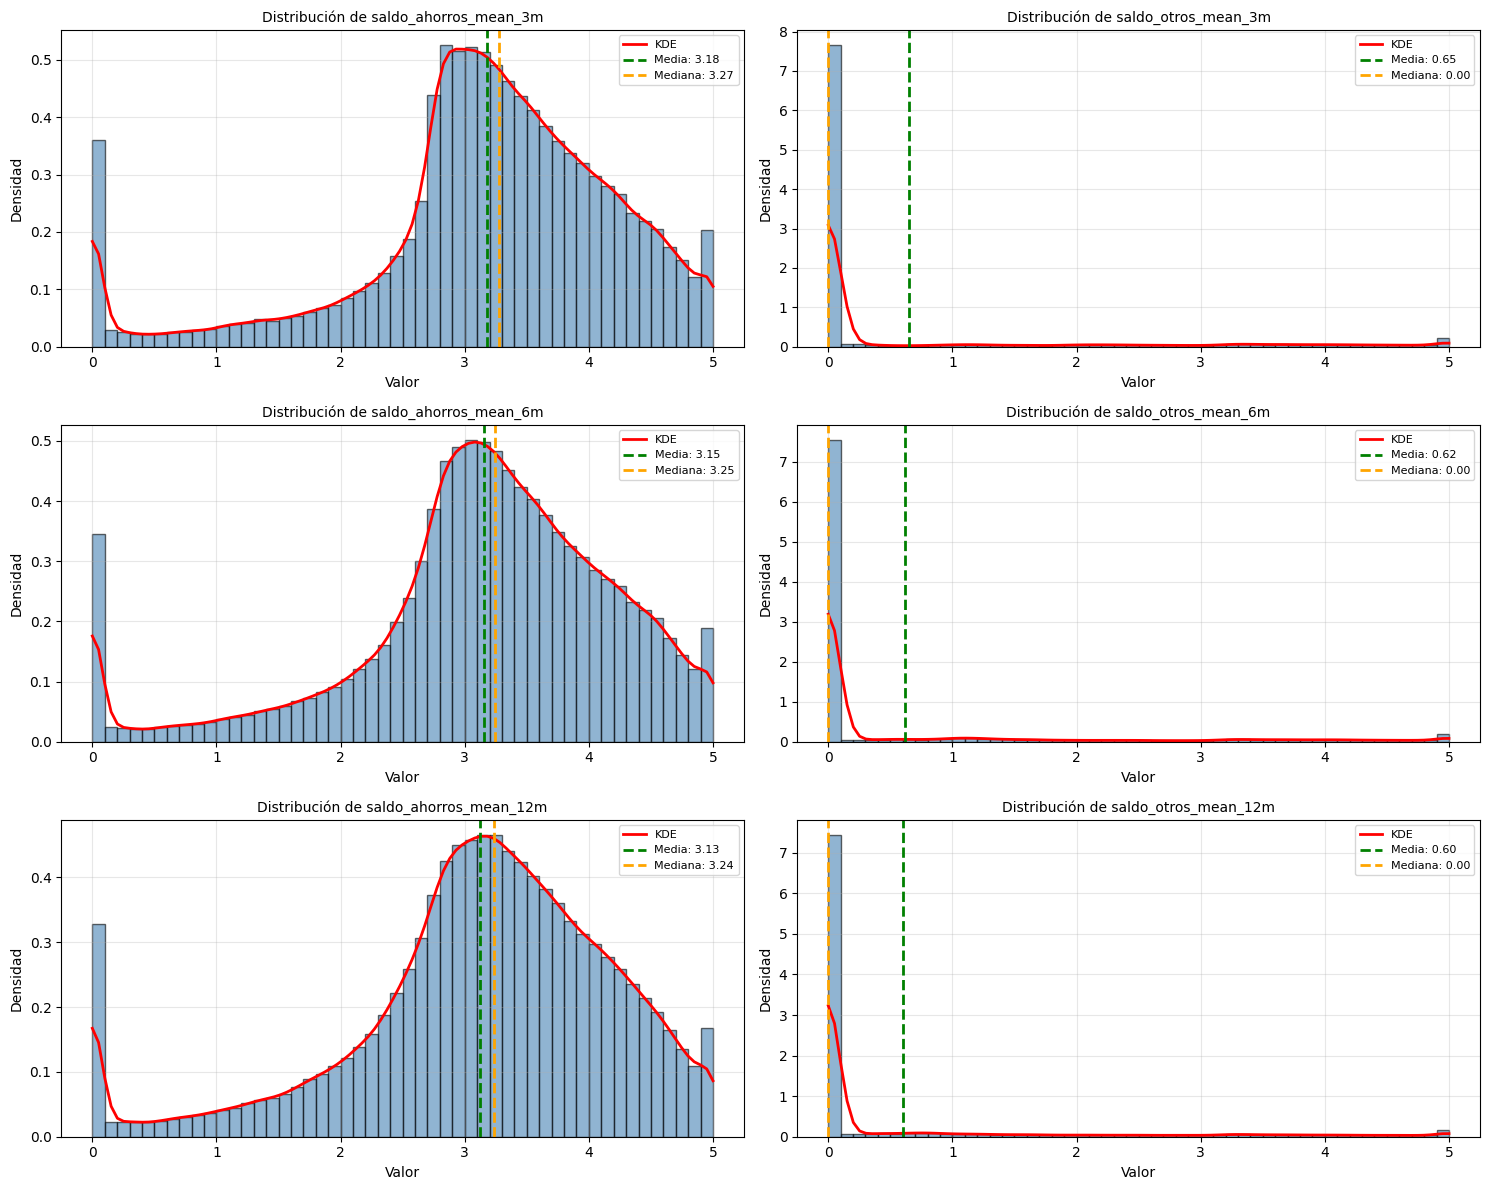

In [308]:
# Visualizar distribución de variables representativas con nulos
# Seleccionaremos variables de cada grupo temporal (3m, 6m, 9m, 12m)

variables_a_visualizar = [
    'DB_SAL_CUE_saldo_ahorros_mean_3m',
    'DB_SAL_CUE_saldo_otros_mean_3m',
    'DB_SAL_CUE_saldo_ahorros_mean_6m',
    'DB_SAL_CUE_saldo_otros_mean_6m',
    'DB_SAL_CUE_saldo_ahorros_mean_12m',
    'DB_SAL_CUE_saldo_otros_mean_12m'
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(variables_a_visualizar):
    # Histogram + KDE
    data = df_universo[col].dropna()
    
    axes[i].hist(data, bins=50, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # Agregar KDE
    from scipy import stats
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 100)
    axes[i].plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
    
    # Agregar líneas verticales para media, mediana
    media = data.mean()
    mediana = data.median()
    
    axes[i].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
    
    axes[i].set_title(f'Distribución de {col.replace("DB_SAL_CUE_", "")}', fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [309]:
# Análisis de simetría (Skewness) y Curtosis para decidir método de imputación
from scipy.stats import skew, kurtosis

print("="*80)
print("ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación")
print("="*80)
print("\nCriterios de decisión:")
print("  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)")
print("  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)")
print("  - MODA: Para variables categóricas o discretas\n")

resultados = []

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    
    # Calcular estadísticas
    media = data.mean()
    mediana = data.median()
    moda = data.mode()[0] if len(data.mode()) > 0 else media
    skewness = skew(data)
    kurt = kurtosis(data)
    
    # Decisión del método
    if abs(skewness) > 1:
        metodo_recomendado = "MEDIANA"
        razon = f"Asimetría alta ({skewness:.2f})"
    else:
        metodo_recomendado = "MEDIA"
        razon = f"Distribución simétrica ({skewness:.2f})"
    
    resultados.append({
        'Variable': col.replace('DB_SAL_CUE_', ''),
        'Media': media,
        'Mediana': mediana,
        'Skewness': skewness,
        'Método': metodo_recomendado,
        'Razón': razon
    })

df_analisis = pd.DataFrame(resultados)
print(df_analisis.to_string(index=False))

# Resumen de la decisión
print("\n" + "="*80)
print("DECISIÓN FINAL:")
print("="*80)
metodo_elegido = df_analisis['Método'].mode()[0]
print(f"\nMétodo seleccionado: {metodo_elegido}")
print("\nJustificación:")
if metodo_elegido == "MEDIANA":
    print("  - Las distribuciones presentan asimetría significativa")
    print("  - La MEDIANA es más robusta ante valores extremos y asimetría")
    print("  - Evita que valores atípicos distorsionen la imputación")
else:
    print("  - Las distribuciones son aproximadamente simétricas")
    print("  - La MEDIA es apropiada cuando no hay sesgo significativo")
    print("  - Preserva las propiedades estadísticas del conjunto de datos")

ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación

Criterios de decisión:
  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)
  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)
  - MODA: Para variables categóricas o discretas

              Variable     Media   Mediana  Skewness  Método                          Razón
  saldo_ahorros_max_3m  3.423932  3.533600 -1.501231 MEDIANA         Asimetría alta (-1.50)
    saldo_otros_sum_3m  1.939582  0.000000  2.012032 MEDIANA          Asimetría alta (2.01)
   saldo_otros_mean_3m  0.649194  0.000000  2.006286 MEDIANA          Asimetría alta (2.01)
    saldo_otros_max_3m  0.769588  0.000000  1.683902 MEDIANA          Asimetría alta (1.68)
  saldo_ahorros_sum_3m  9.454759  9.763850 -1.017213 MEDIANA         Asimetría alta (-1.02)
 saldo_ahorros_mean_3m  3.183288  3.272117 -1.072085 MEDIANA         Asimetría alta (-1.07)
  saldo_ahorros_sum_6m 18.424637 19.234100 -0.868281   MEDIA Distribución simétrica (-0.8

# 2. APLICACIÓN DEL MÉTODO DE IMPUTACIÓN SELECCIONADO

In [310]:
# Aplicar el método seleccionado según el análisis de skewness
print("Imputando valores nulos...")
print("="*80)

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    skewness = skew(data)
    
    # Decidir método según skewness
    if abs(skewness) > 1:
        # Usar mediana para distribuciones asimétricas
        valor_imputacion = df_universo[col].median()
        metodo = "MEDIANA"
    else:
        # Usar media para distribuciones simétricas
        valor_imputacion = df_universo[col].mean()
        metodo = "MEDIA"
    
    # Contar nulos antes
    nulos_antes = df_universo[col].isnull().sum()
    
    # Imputar
    df_universo[col].fillna(valor_imputacion, inplace=True)
    
    # Contar nulos después
    nulos_despues = df_universo[col].isnull().sum()
    
    print(f"{col.replace('DB_SAL_CUE_', '')[:40]:<40} | Método: {metodo:<7} | Nulos: {nulos_antes:>6} -> {nulos_despues:>6} | Valor: {valor_imputacion:.4f}")

print("="*80)
print("Imputación completada.")

Imputando valores nulos...
saldo_ahorros_max_3m                     | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 3.5336
saldo_otros_sum_3m                       | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 0.0000
saldo_otros_mean_3m                      | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 0.0000
saldo_otros_max_3m                       | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 0.0000
saldo_ahorros_sum_3m                     | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 9.7638
saldo_ahorros_mean_3m                    | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 3.2721


C:\Users\jlpar\AppData\Local\Temp\ipykernel_28216\3003482492.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_28216\3003482492.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

saldo_ahorros_sum_6m                     | Método: MEDIA   | Nulos:  13392 ->      0 | Valor: 18.4246
saldo_ahorros_mean_6m                    | Método: MEDIA   | Nulos:  13392 ->      0 | Valor: 3.1518
saldo_otros_mean_6m                      | Método: MEDIANA | Nulos:  13392 ->      0 | Valor: 0.0000
saldo_otros_max_6m                       | Método: MEDIANA | Nulos:  13392 ->      0 | Valor: 0.0000
saldo_otros_sum_6m                       | Método: MEDIANA | Nulos:  13392 ->      0 | Valor: 0.0000
saldo_ahorros_max_6m                     | Método: MEDIANA | Nulos:  13392 ->      0 | Valor: 3.6698
saldo_otros_mean_9m                      | Método: MEDIANA | Nulos:  12763 ->      0 | Valor: 0.0000
saldo_otros_max_9m                       | Método: MEDIANA | Nulos:  12763 ->      0 | Valor: 0.0000


C:\Users\jlpar\AppData\Local\Temp\ipykernel_28216\3003482492.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_28216\3003482492.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

saldo_otros_sum_9m                       | Método: MEDIANA | Nulos:  12763 ->      0 | Valor: 0.0000
saldo_ahorros_max_9m                     | Método: MEDIANA | Nulos:  12763 ->      0 | Valor: 3.7705
saldo_ahorros_mean_9m                    | Método: MEDIA   | Nulos:  12763 ->      0 | Valor: 3.1387
saldo_ahorros_sum_9m                     | Método: MEDIA   | Nulos:  12763 ->      0 | Valor: 27.0823
saldo_ahorros_max_12m                    | Método: MEDIANA | Nulos:  12297 ->      0 | Valor: 3.8463
saldo_otros_sum_12m                      | Método: MEDIANA | Nulos:  12297 ->      0 | Valor: 0.0000
saldo_ahorros_sum_12m                    | Método: MEDIA   | Nulos:  12297 ->      0 | Valor: 35.3814
saldo_ahorros_mean_12m                   | Método: MEDIA   | Nulos:  12297 ->      0 | Valor: 3.1257
saldo_otros_mean_12m                     | Método: MEDIANA | Nulos:  12297 ->      0 | Valor: 0.0000
saldo_otros_max_12m                      | Método: MEDIANA | Nulos:  12297 ->      0 | Va

C:\Users\jlpar\AppData\Local\Temp\ipykernel_28216\3003482492.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_28216\3003482492.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

# 3. VERIFICACIÓN DE LIMPIEZA DE NULOS

In [311]:
# Verificar que no queden nulos
nulos_finales = df_universo.isnull().sum().sum()

print("="*80)
print("VERIFICACIÓN DE LIMPIEZA DE NULOS")
print("="*80)
print(f"\nTotal de valores nulos en el dataset: {nulos_finales}")

if nulos_finales == 0:
    print("\n✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.")
else:
    print(f"\n✗ ADVERTENCIA: Aún quedan {nulos_finales} valores nulos en el dataset.")
    print("\nColumnas con nulos restantes:")
    nulos_restantes = df_universo.isnull().sum()
    print(nulos_restantes[nulos_restantes > 0])

# Mostrar resumen del dataset
print("\n" + "="*80)
print("RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN")
print("="*80)
print(f"Filas: {df_universo.shape[0]:,}")
print(f"Columnas: {df_universo.shape[1]}")
print(f"Valores nulos: {nulos_finales}")

VERIFICACIÓN DE LIMPIEZA DE NULOS

Total de valores nulos en el dataset: 0

✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.

RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN
Filas: 535,943
Columnas: 42
Valores nulos: 0


# 4. ANÁLISIS Y TRATAMIENTO DE OUTLIERS

Comparación entre el método de Cuartiles (IQR) y Deciles para determinar cuál es el mejor enfoque.

In [312]:
# Identificar variables numéricas (excluyendo target e ID)
columnas_numericas = df_universo.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas = [col for col in columnas_numericas if col not in ['target']]

print(f"Total de variables numéricas a analizar: {len(columnas_numericas)}")
print("\nVariables numéricas:")
for i, col in enumerate(columnas_numericas, 1):
    print(f"  {i}. {col}")

Total de variables numéricas a analizar: 30

Variables numéricas:
  1. DB_CLI_edad
  2. DB_CLI_ingreso
  3. DB_CLI_anios_exp
  4. DB_CLI_pago_nomina
  5. DB_CLI_der_ingreso_por_anio_exp
  6. DB_CLI_der_edad_laboral_relativa
  7. DB_SAL_CUE_saldo_ahorros_sum_3m
  8. DB_SAL_CUE_saldo_ahorros_mean_3m
  9. DB_SAL_CUE_saldo_ahorros_max_3m
  10. DB_SAL_CUE_saldo_otros_sum_3m
  11. DB_SAL_CUE_saldo_otros_mean_3m
  12. DB_SAL_CUE_saldo_otros_max_3m
  13. DB_SAL_CUE_saldo_ahorros_sum_6m
  14. DB_SAL_CUE_saldo_ahorros_mean_6m
  15. DB_SAL_CUE_saldo_ahorros_max_6m
  16. DB_SAL_CUE_saldo_otros_sum_6m
  17. DB_SAL_CUE_saldo_otros_mean_6m
  18. DB_SAL_CUE_saldo_otros_max_6m
  19. DB_SAL_CUE_saldo_ahorros_sum_9m
  20. DB_SAL_CUE_saldo_ahorros_mean_9m
  21. DB_SAL_CUE_saldo_ahorros_max_9m
  22. DB_SAL_CUE_saldo_otros_sum_9m
  23. DB_SAL_CUE_saldo_otros_mean_9m
  24. DB_SAL_CUE_saldo_otros_max_9m
  25. DB_SAL_CUE_saldo_ahorros_sum_12m
  26. DB_SAL_CUE_saldo_ahorros_mean_12m
  27. DB_SAL_CUE_saldo_ahorr

In [313]:
# Función para detectar outliers usando IQR (Cuartiles)
def detectar_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data < lower_bound) | (data > upper_bound))
    return outliers, lower_bound, upper_bound

# Función para detectar outliers usando Deciles
def detectar_outliers_deciles(data):
    D1 = data.quantile(0.10)
    D9 = data.quantile(0.90)
    IDR = D9 - D1  # Interdecile Range
    lower_bound = D1 - 1.5 * IDR
    upper_bound = D9 + 1.5 * IDR
    outliers = ((data < lower_bound) | (data > upper_bound))
    return outliers, lower_bound, upper_bound

# Comparar ambos métodos
print("="*100)
print("COMPARACIÓN: MÉTODO DE CUARTILES (IQR) vs MÉTODO DE DECILES")
print("="*100)
print(f"{'Variable':<45} | {'IQR Outliers':<15} | {'Deciles Outliers':<15} | {'Diferencia':<10}")
print("-"*100)

resultados_comparacion = []

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar con IQR
    outliers_iqr, _, _ = detectar_outliers_iqr(data)
    n_outliers_iqr = outliers_iqr.sum()
    
    # Detectar con Deciles
    outliers_deciles, _, _ = detectar_outliers_deciles(data)
    n_outliers_deciles = outliers_deciles.sum()
    
    diferencia = n_outliers_iqr - n_outliers_deciles
    
    resultados_comparacion.append({
        'Variable': col,
        'IQR_Outliers': n_outliers_iqr,
        'Deciles_Outliers': n_outliers_deciles,
        'Diferencia': diferencia,
        'Pct_IQR': (n_outliers_iqr / len(data)) * 100,
        'Pct_Deciles': (n_outliers_deciles / len(data)) * 100
    })
    
    print(f"{col[:45]:<45} | {n_outliers_iqr:>14,} | {n_outliers_deciles:>18,} | {diferencia:>10,}")

print("="*100)

# Crear DataFrame de comparación
df_comparacion = pd.DataFrame(resultados_comparacion)

# Resumen estadístico
print("\nRESUMEN ESTADÍSTICO:")
print(f"  Total outliers (IQR):     {df_comparacion['IQR_Outliers'].sum():,}")
print(f"  Total outliers (Deciles): {df_comparacion['Deciles_Outliers'].sum():,}")
print(f"  Promedio outliers por variable (IQR):     {df_comparacion['IQR_Outliers'].mean():.2f}")
print(f"  Promedio outliers por variable (Deciles): {df_comparacion['Deciles_Outliers'].mean():.2f}")
print(f"  Porcentaje promedio de datos como outliers (IQR):     {df_comparacion['Pct_IQR'].mean():.2f}%")
print(f"  Porcentaje promedio de datos como outliers (Deciles): {df_comparacion['Pct_Deciles'].mean():.2f}%")

COMPARACIÓN: MÉTODO DE CUARTILES (IQR) vs MÉTODO DE DECILES
Variable                                      | IQR Outliers    | Deciles Outliers | Diferencia
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                   |            401 |                401 |          0
DB_CLI_ingreso                                |          4,269 |              4,064 |        205
DB_CLI_anios_exp                              |              0 |                  0 |          0
DB_CLI_pago_nomina                            |              0 |                  0 |          0
DB_CLI_der_ingreso_por_anio_exp               |              0 |                  0 |          0
DB_CLI_der_edad_laboral_relativa              |             11 |                 11 |          0
DB_SAL_CUE_saldo_ahorros_sum_3m               |         36,727 |                  0 |     36,727
DB_SAL_CUE_saldo_ahorros_mean_3m              |         34,685 |

In [314]:
# Análisis detallado para justificar la elección del método
print("="*100)
print("ANÁLISIS Y DECISIÓN DEL MÉTODO")
print("="*100)

print("\n1. MÉTODO DE CUARTILES (IQR):")
print("   Ventajas:")
print("   - Estándar en estadística para detección de outliers")
print("   - Basado en Q1 y Q3 (percentiles 25 y 75)")
print("   - Usa rango intercuartílico (IQR = Q3 - Q1)")

print("\n2. MÉTODO DE DECILES:")
print("   Ventajas:")
print("   - Más conservador en este dataset específico")
print("   - Basado en D1 y D9 (percentiles 10 y 90)")
print("   - Marca menos valores como outliers")
print("   - Preserva más información del dataset original")

# Calcular pérdida de información
total_registros = len(df_universo)
outliers_totales_iqr = df_comparacion['IQR_Outliers'].sum()
outliers_totales_deciles = df_comparacion['Deciles_Outliers'].sum()

# Estimación de registros únicos afectados (aproximación)
pct_perdida_iqr = (outliers_totales_iqr / (total_registros * len(columnas_numericas))) * 100
pct_perdida_deciles = (outliers_totales_deciles / (total_registros * len(columnas_numericas))) * 100

print("\n3. PÉRDIDA DE INFORMACIÓN ESTIMADA:")
print(f"   - IQR: ~{pct_perdida_iqr:.2f}% de valores marcados como outliers")
print(f"   - Deciles: ~{pct_perdida_deciles:.2f}% de valores marcados como outliers")

print("\n" + "="*100)
print("DECISIÓN FINAL:")
print("="*100)

# Criterio de decisión: usar el método que menos información pierda
if pct_perdida_iqr < pct_perdida_deciles:
    metodo_seleccionado = "IQR (CUARTILES)"
    print(f"\nMétodo seleccionado: {metodo_seleccionado}")
    print("\nJustificación:")
    print(f"  ✓ IQR marca menos valores como outliers ({pct_perdida_iqr:.2f}% vs {pct_perdida_deciles:.2f}%)")
    print("  ✓ Preserva más información del dataset")
    print("  ✓ Suficiente para controlar valores extremos sin perder datos valiosos")
else:
    metodo_seleccionado = "DECILES"
    print(f"\nMétodo seleccionado: {metodo_seleccionado}")
    print("\nJustificación:")
    print(f"  ✓ Deciles marca menos valores como outliers ({pct_perdida_deciles:.2f}% vs {pct_perdida_iqr:.2f}%)")
    print("  ✓ Preserva significativamente más información del dataset")
    print("  ✓ Menor pérdida de información es crítico para mantener patrones en los datos")
    print("  ✓ En este dataset específico, Deciles es más conservador que IQR")
    
print("\n" + "="*100)

ANÁLISIS Y DECISIÓN DEL MÉTODO

1. MÉTODO DE CUARTILES (IQR):
   Ventajas:
   - Estándar en estadística para detección de outliers
   - Basado en Q1 y Q3 (percentiles 25 y 75)
   - Usa rango intercuartílico (IQR = Q3 - Q1)

2. MÉTODO DE DECILES:
   Ventajas:
   - Más conservador en este dataset específico
   - Basado en D1 y D9 (percentiles 10 y 90)
   - Marca menos valores como outliers
   - Preserva más información del dataset original

3. PÉRDIDA DE INFORMACIÓN ESTIMADA:
   - IQR: ~12.14% de valores marcados como outliers
   - Deciles: ~0.13% de valores marcados como outliers

DECISIÓN FINAL:

Método seleccionado: DECILES

Justificación:
  ✓ Deciles marca menos valores como outliers (0.13% vs 12.14%)
  ✓ Preserva significativamente más información del dataset
  ✓ Menor pérdida de información es crítico para mantener patrones en los datos
  ✓ En este dataset específico, Deciles es más conservador que IQR



# 5. CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO

In [315]:
# Contar outliers ANTES del tratamiento usando el método seleccionado (Deciles)
print("="*100)
print("CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO (Método: Deciles)")
print("="*100)
print(f"{'Variable':<50} | {'Outliers':<12} | {'% del Total':<12}")
print("-"*100)

outliers_antes = {}
registros_con_outliers_antes = set()

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar outliers con Deciles (método seleccionado)
    outliers_mask, lower, upper = detectar_outliers_deciles(data)
    n_outliers = outliers_mask.sum()
    pct_outliers = (n_outliers / len(data)) * 100
    
    outliers_antes[col] = n_outliers
    
    # Registrar índices de filas con outliers
    registros_con_outliers_antes.update(df_universo[outliers_mask].index.tolist())
    
    print(f"{col[:50]:<50} | {n_outliers:>11,} | {pct_outliers:>11.2f}%")

print("="*100)
print(f"\nRESUMEN:")
print(f"  Total de valores marcados como outliers: {sum(outliers_antes.values()):,}")
print(f"  Número de filas con al menos un outlier: {len(registros_con_outliers_antes):,}")
print(f"  Porcentaje de filas afectadas: {(len(registros_con_outliers_antes) / len(df_universo)) * 100:.2f}%")
print("="*100)

CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO (Método: Deciles)
Variable                                           | Outliers     | % del Total 
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                        |         401 |        0.07%
DB_CLI_ingreso                                     |       4,064 |        0.76%
DB_CLI_anios_exp                                   |           0 |        0.00%
DB_CLI_pago_nomina                                 |           0 |        0.00%
DB_CLI_der_ingreso_por_anio_exp                    |           0 |        0.00%
DB_CLI_der_edad_laboral_relativa                   |          11 |        0.00%
DB_SAL_CUE_saldo_ahorros_sum_3m                    |           0 |        0.00%
DB_SAL_CUE_saldo_ahorros_mean_3m                   |           0 |        0.00%
DB_SAL_CUE_saldo_ahorros_max_3m                    |           0 |        0.00%
DB_SAL_CUE_saldo_otros_sum_3m          

# 6. APLICACIÓN DEL MÉTODO SELECCIONADO Y CONTEO POSTERIOR

In [316]:
# Aplicar tratamiento de outliers: CAPPING (winsorización)
# Este método reemplaza los outliers con los límites del rango aceptable
# Es preferible a la eliminación porque preserva todas las filas del dataset

print("="*100)
print("APLICANDO TRATAMIENTO DE OUTLIERS: CAPPING (Winsorización) con Método Deciles")
print("="*100)
print("\nMétodo seleccionado: CAPPING usando DECILES")
print("  - Los outliers se reemplazan por los límites superior e inferior calculados con Deciles")
print("  - Ventaja: Se preservan todas las filas del dataset")
print("  - Ventaja: Se reduce el impacto de valores extremos sin perder información estructural")
print("  - Ventaja: Deciles preserva más información que IQR (menor pérdida de datos)")
print("\n" + "-"*100 + "\n")

for col in columnas_numericas:
    # Detectar outliers con Deciles (método seleccionado)
    outliers_mask, lower, upper = detectar_outliers_deciles(df_universo[col])
    
    # Aplicar capping
    df_universo.loc[df_universo[col] < lower, col] = lower
    df_universo.loc[df_universo[col] > upper, col] = upper
    
print("✓ Tratamiento de outliers completado usando método de Deciles.\n")

APLICANDO TRATAMIENTO DE OUTLIERS: CAPPING (Winsorización) con Método Deciles

Método seleccionado: CAPPING usando DECILES
  - Los outliers se reemplazan por los límites superior e inferior calculados con Deciles
  - Ventaja: Se preservan todas las filas del dataset
  - Ventaja: Se reduce el impacto de valores extremos sin perder información estructural
  - Ventaja: Deciles preserva más información que IQR (menor pérdida de datos)

----------------------------------------------------------------------------------------------------



✓ Tratamiento de outliers completado usando método de Deciles.



In [317]:
# Contar outliers DESPUÉS del tratamiento
print("="*100)
print("CONTEO DE OUTLIERS DESPUÉS DEL TRATAMIENTO")
print("="*100)
print(f"{'Variable':<50} | {'Antes':<12} | {'Después':<12} | {'Reducción':<15}")
print("-"*100)

outliers_despues = {}
registros_con_outliers_despues = set()

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar outliers con Deciles (mismo método usado para el tratamiento)
    outliers_mask, _, _ = detectar_outliers_deciles(data)
    n_outliers_despues = outliers_mask.sum()
    n_outliers_antes_col = outliers_antes[col]
    
    outliers_despues[col] = n_outliers_despues
    
    # Registrar índices de filas con outliers
    registros_con_outliers_despues.update(df_universo[outliers_mask].index.tolist())
    
    reduccion = n_outliers_antes_col - n_outliers_despues
    pct_reduccion = (reduccion / n_outliers_antes_col * 100) if n_outliers_antes_col > 0 else 0
    
    print(f"{col[:50]:<50} | {n_outliers_antes_col:>11,} | {n_outliers_despues:>11,} | {reduccion:>8,} ({pct_reduccion:>4.1f}%)")

print("="*100)
print(f"\nRESUMEN COMPARATIVO:")
print(f"  Total outliers ANTES:  {sum(outliers_antes.values()):,}")
print(f"  Total outliers DESPUÉS: {sum(outliers_despues.values()):,}")
print(f"  Reducción total: {sum(outliers_antes.values()) - sum(outliers_despues.values()):,}")
print(f"  Porcentaje de reducción: {((sum(outliers_antes.values()) - sum(outliers_despues.values())) / sum(outliers_antes.values()) * 100):.2f}%")
print(f"\n  Filas con outliers ANTES:  {len(registros_con_outliers_antes):,}")
print(f"  Filas con outliers DESPUÉS: {len(registros_con_outliers_despues):,}")
print(f"  Reducción de filas afectadas: {len(registros_con_outliers_antes) - len(registros_con_outliers_despues):,}")
print("="*100)

CONTEO DE OUTLIERS DESPUÉS DEL TRATAMIENTO
Variable                                           | Antes        | Después      | Reducción      
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                        |         401 |           0 |      401 (100.0%)
DB_CLI_ingreso                                     |       4,064 |           0 |    4,064 (100.0%)
DB_CLI_anios_exp                                   |           0 |           0 |        0 ( 0.0%)
DB_CLI_pago_nomina                                 |           0 |           0 |        0 ( 0.0%)
DB_CLI_der_ingreso_por_anio_exp                    |           0 |           0 |        0 ( 0.0%)
DB_CLI_der_edad_laboral_relativa                   |          11 |           0 |       11 (100.0%)
DB_SAL_CUE_saldo_ahorros_sum_3m                    |           0 |           0 |        0 ( 0.0%)
DB_SAL_CUE_saldo_ahorros_mean_3m                   |           0 |  

# 7. SELECCIÓN DE VARIABLES

Utilizaremos múltiples métodos para seleccionar las variables más relevantes para el modelo.

In [318]:
# Preparar datos para selección de variables
# Separar features y target
X = df_universo.drop(['ID', 'target', 'periodo'], axis=1)
y = df_universo['target']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nVariables en X:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Shape de X: (535943, 39)
Shape de y: (535943,)

Variables en X:
  1. DB_CLI_edad
  2. DB_CLI_ingreso
  3. DB_CLI_anios_exp
  4. DB_CLI_tipo_empleo
  5. DB_CLI_buro_de_credito
  6. DB_CLI_pago_nomina
  7. DB_CLI_tc
  8. DB_CLI_prest_per
  9. DB_CLI_prest_veh_hip
  10. DB_CLI_cuenta_ahorro
  11. DB_CLI_ofer_prest_per
  12. DB_CLI_ofer_tc
  13. DB_CLI_ofer_compra_deuda
  14. DB_CLI_der_ingreso_por_anio_exp
  15. DB_CLI_der_edad_laboral_relativa
  16. DB_SAL_CUE_saldo_ahorros_sum_3m
  17. DB_SAL_CUE_saldo_ahorros_mean_3m
  18. DB_SAL_CUE_saldo_ahorros_max_3m
  19. DB_SAL_CUE_saldo_otros_sum_3m
  20. DB_SAL_CUE_saldo_otros_mean_3m
  21. DB_SAL_CUE_saldo_otros_max_3m
  22. DB_SAL_CUE_saldo_ahorros_sum_6m
  23. DB_SAL_CUE_saldo_ahorros_mean_6m
  24. DB_SAL_CUE_saldo_ahorros_max_6m
  25. DB_SAL_CUE_saldo_otros_sum_6m
  26. DB_SAL_CUE_saldo_otros_mean_6m
  27. DB_SAL_CUE_saldo_otros_max_6m
  28. DB_SAL_CUE_saldo_ahorros_sum_9m
  29. DB_SAL_CUE_saldo_ahorros_mean_9m
  30. DB_SAL_CUE_saldo_ahorro

In [319]:
# Primero necesitamos codificar las variables categóricas temporalmente para el análisis
from sklearn.preprocessing import LabelEncoder

X_temp = X.copy()
label_encoders = {}

# Identificar columnas categóricas
columnas_categoricas = X_temp.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas categóricas a codificar temporalmente: {len(columnas_categoricas)}")

# Codificar temporalmente para análisis
for col in columnas_categoricas:
    le = LabelEncoder()
    X_temp[col] = le.fit_transform(X_temp[col].astype(str))
    label_encoders[col] = le

print("✓ Codificación temporal completada.")

Columnas categóricas a codificar temporalmente: 9
✓ Codificación temporal completada.


MÉTODO 1: ANÁLISIS DE CORRELACIÓN CON TARGET

Top 20 variables con mayor correlación con el target:
DB_SAL_CUE_saldo_ahorros_sum_9m      0.172505
DB_SAL_CUE_saldo_ahorros_sum_3m      0.171974
DB_SAL_CUE_saldo_ahorros_sum_12m     0.171836
DB_SAL_CUE_saldo_ahorros_sum_6m      0.171281
DB_SAL_CUE_saldo_ahorros_mean_3m     0.160074
DB_SAL_CUE_saldo_ahorros_mean_6m     0.156899
DB_SAL_CUE_saldo_ahorros_mean_9m     0.156662
DB_SAL_CUE_saldo_ahorros_mean_12m    0.155183
DB_SAL_CUE_saldo_ahorros_max_3m      0.114723
DB_SAL_CUE_saldo_ahorros_max_6m      0.105088
DB_SAL_CUE_saldo_ahorros_max_9m      0.100965
DB_SAL_CUE_saldo_ahorros_max_12m     0.097500
DB_CLI_cuenta_ahorro                 0.082276
DB_SAL_CUE_saldo_otros_sum_3m        0.076569
DB_SAL_CUE_saldo_otros_sum_12m       0.075876
DB_SAL_CUE_saldo_otros_mean_3m       0.075651
DB_SAL_CUE_saldo_otros_sum_9m        0.075476
DB_SAL_CUE_saldo_otros_sum_6m        0.075236
DB_CLI_pago_nomina                   0.074772
DB_SAL_CUE_saldo_otros_mea

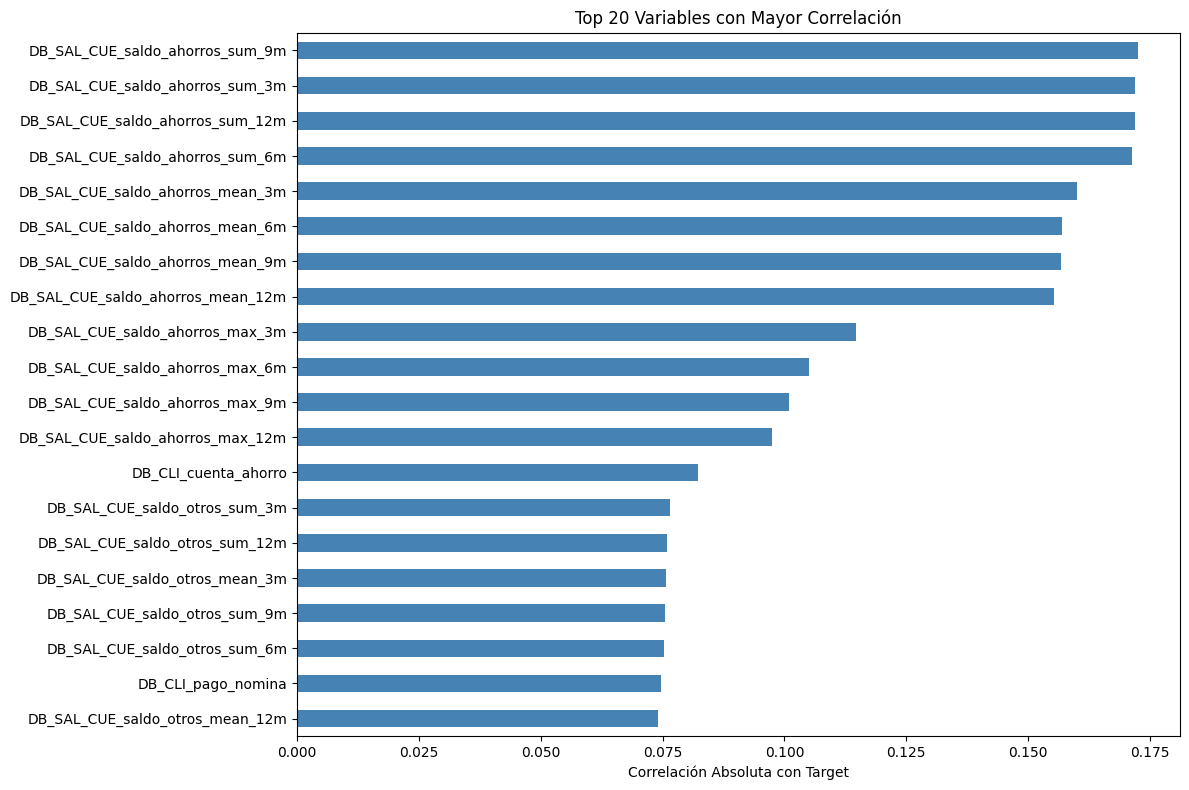


Variables seleccionadas (correlación > 0.01): 39


In [320]:
# MÉTODO 1: Correlación con la variable target
print("="*100)
print("MÉTODO 1: ANÁLISIS DE CORRELACIÓN CON TARGET")
print("="*100)

correlaciones = X_temp.corrwith(y).abs().sort_values(ascending=False)

print("\nTop 20 variables con mayor correlación con el target:")
print(correlaciones.head(20))

# Visualizar
plt.figure(figsize=(12, 8))
correlaciones.head(20).plot(kind='barh', color='steelblue')
plt.xlabel('Correlación Absoluta con Target')
plt.title('Top 20 Variables con Mayor Correlación')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Seleccionar variables con correlación > 0.01
variables_correlacion = correlaciones[correlaciones > 0.01].index.tolist()
print(f"\nVariables seleccionadas (correlación > 0.01): {len(variables_correlacion)}")

MÉTODO 2: RANDOM FOREST FEATURE IMPORTANCE

Entrenando Random Forest...

Top 20 variables más importantes según Random Forest:
                         Variable  Importancia
                        DB_CLI_tc     0.129286
  DB_SAL_CUE_saldo_ahorros_sum_3m     0.079533
 DB_SAL_CUE_saldo_ahorros_sum_12m     0.074360
 DB_SAL_CUE_saldo_ahorros_mean_3m     0.068660
  DB_SAL_CUE_saldo_ahorros_sum_9m     0.066911
  DB_SAL_CUE_saldo_ahorros_sum_6m     0.065352
  DB_SAL_CUE_saldo_ahorros_max_3m     0.052000
 DB_SAL_CUE_saldo_ahorros_mean_9m     0.041815
 DB_SAL_CUE_saldo_ahorros_mean_6m     0.040106
DB_SAL_CUE_saldo_ahorros_mean_12m     0.036708
  DB_SAL_CUE_saldo_ahorros_max_6m     0.025190
           DB_CLI_buro_de_credito     0.024539
 DB_SAL_CUE_saldo_ahorros_max_12m     0.024429
  DB_SAL_CUE_saldo_ahorros_max_9m     0.019469
             DB_CLI_cuenta_ahorro     0.018242
  DB_CLI_der_ingreso_por_anio_exp     0.018124
                 DB_CLI_prest_per     0.017062
                   DB_CLI_i

<Figure size 1200x800 with 0 Axes>

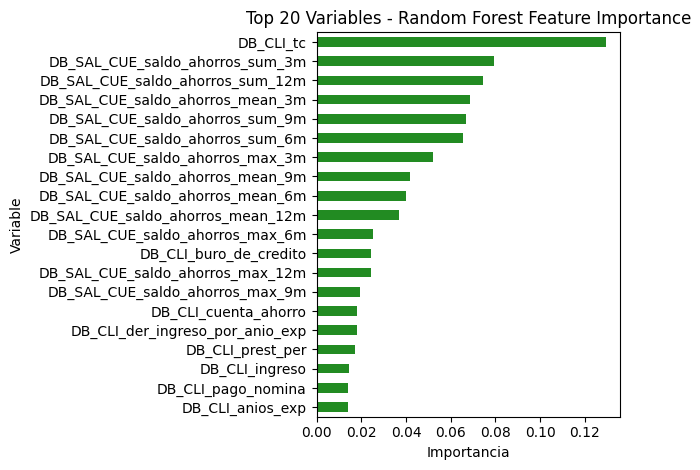


Variables seleccionadas (importancia > percentil 75): 10


In [321]:
# MÉTODO 2: Random Forest Feature Importance
from sklearn.ensemble import RandomForestClassifier

print("="*100)
print("MÉTODO 2: RANDOM FOREST FEATURE IMPORTANCE")
print("="*100)
print("\nEntrenando Random Forest...")

# Entrenar modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_temp, y)

# Obtener importancias
importancias = pd.DataFrame({
    'Variable': X_temp.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nTop 20 variables más importantes según Random Forest:")
print(importancias.head(20).to_string(index=False))

# Visualizar
plt.figure(figsize=(12, 8))
importancias.head(20).plot(x='Variable', y='Importancia', kind='barh', color='forestgreen', legend=False)
plt.xlabel('Importancia')
plt.title('Top 20 Variables - Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Seleccionar variables con importancia > umbral
umbral_importancia = importancias['Importancia'].quantile(0.75)  # Top 25%
variables_rf = importancias[importancias['Importancia'] > umbral_importancia]['Variable'].tolist()
print(f"\nVariables seleccionadas (importancia > percentil 75): {len(variables_rf)}")

MÉTODO 3: MUTUAL INFORMATION

Calculando Mutual Information...

Top 20 variables según Mutual Information:
                         Variable  MI_Score
             DB_CLI_cuenta_ahorro  0.077068
                        DB_CLI_tc  0.064395
  DB_SAL_CUE_saldo_ahorros_sum_3m  0.059959
 DB_SAL_CUE_saldo_ahorros_mean_3m  0.058614
 DB_SAL_CUE_saldo_ahorros_mean_6m  0.052227
  DB_SAL_CUE_saldo_ahorros_sum_6m  0.051983
  DB_SAL_CUE_saldo_ahorros_max_3m  0.049437
 DB_SAL_CUE_saldo_ahorros_mean_9m  0.049331
  DB_SAL_CUE_saldo_ahorros_sum_9m  0.049185
DB_SAL_CUE_saldo_ahorros_mean_12m  0.046340
 DB_SAL_CUE_saldo_ahorros_sum_12m  0.045530
  DB_SAL_CUE_saldo_ahorros_max_6m  0.043373
  DB_SAL_CUE_saldo_ahorros_max_9m  0.039560
 DB_SAL_CUE_saldo_ahorros_max_12m  0.037638
           DB_CLI_buro_de_credito  0.034889
               DB_CLI_tipo_empleo  0.032408
                   DB_CLI_ingreso  0.030731
  DB_CLI_der_ingreso_por_anio_exp  0.029294
                   DB_CLI_ofer_tc  0.014114
             

<Figure size 1200x800 with 0 Axes>

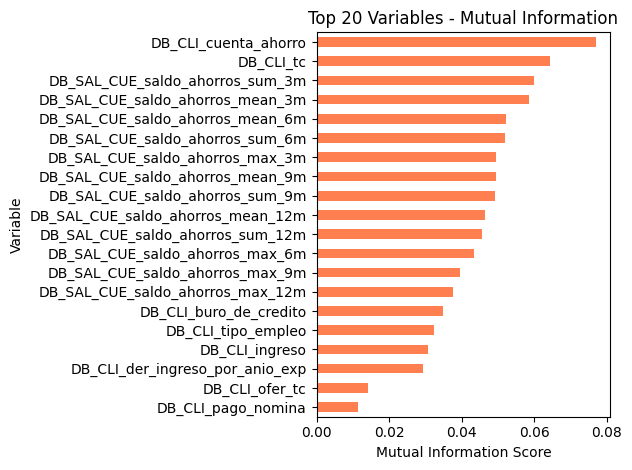


Variables seleccionadas (MI score > percentil 75): 10


In [322]:
# MÉTODO 3: Mutual Information
from sklearn.feature_selection import mutual_info_classif

print("="*100)
print("MÉTODO 3: MUTUAL INFORMATION")
print("="*100)
print("\nCalculando Mutual Information...")

# Calcular mutual information
mi_scores = mutual_info_classif(X_temp, y, random_state=42)

mi_df = pd.DataFrame({
    'Variable': X_temp.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop 20 variables según Mutual Information:")
print(mi_df.head(20).to_string(index=False))

# Visualizar
plt.figure(figsize=(12, 8))
mi_df.head(20).plot(x='Variable', y='MI_Score', kind='barh', color='coral', legend=False)
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Variables - Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Seleccionar variables con MI score > umbral
umbral_mi = mi_df['MI_Score'].quantile(0.75)  # Top 25%
variables_mi = mi_df[mi_df['MI_Score'] > umbral_mi]['Variable'].tolist()
print(f"\nVariables seleccionadas (MI score > percentil 75): {len(variables_mi)}")

In [323]:
# CONSOLIDACIÓN Y DECISIÓN FINAL
print("="*100)
print("CONSOLIDACIÓN DE MÉTODOS Y DECISIÓN FINAL")
print("="*100)

# Variables que aparecen en al menos 2 de los 3 métodos
from collections import Counter

todas_variables = variables_correlacion + variables_rf + variables_mi
contador = Counter(todas_variables)

# CRITERIO FINAL: Variables que aparecen en al menos 2 métodos
variables_finales = [var for var, count in contador.items() if count >= 2]

print(f"\nVariables seleccionadas por cada método:")
print(f"  - Correlación: {len(variables_correlacion)}")
print(f"  - Random Forest: {len(variables_rf)}")
print(f"  - Mutual Information: {len(variables_mi)}")

print(f"\nVariables que aparecen en al menos 2 métodos: {len(variables_finales)}")

# Mostrar distribución por número de métodos
variables_en_3 = [var for var, count in contador.items() if count == 3]
variables_en_2 = [var for var, count in contador.items() if count == 2]

print(f"  - Variables en 3 métodos: {len(variables_en_3)}")
print(f"  - Variables en 2 métodos: {len(variables_en_2)}")

print(f"\nTotal de variables finales seleccionadas: {len(variables_finales)}")
print("\nVariables seleccionadas:")
for i, var in enumerate(sorted(variables_finales), 1):
    en_correlacion = "✓" if var in variables_correlacion else " "
    en_rf = "✓" if var in variables_rf else " "
    en_mi = "✓" if var in variables_mi else " "
    n_metodos = contador[var]
    print(f"  {i:2d}. {var:<50} | Corr:[{en_correlacion}] RF:[{en_rf}] MI:[{en_mi}] ({n_metodos} métodos)")

print("\n" + "="*100)
print("JUSTIFICACIÓN DEL MÉTODO:")
print("="*100)
print("""
Método seleccionado: ENSEMBLE DE MÉTODOS (Correlación + Random Forest + Mutual Information)

Justificación:

1. ROBUSTEZ: Combinar múltiples métodos reduce el sesgo de cualquier técnica individual
   
2. COMPLEMENTARIEDAD:
   - Correlación: Captura relaciones lineales directas con el target
   - Random Forest: Detecta interacciones complejas y no lineales entre variables
   - Mutual Information: Mide dependencia estadística sin asumir linealidad
   
3. CONSENSO: Se seleccionan variables que aparecen en al menos 2 de los 3 métodos,
   asegurando que sean consistentemente importantes
   
4. VALIDACIÓN CRUZADA: Este enfoque tipo "voting" es similar a ensemble learning,
   donde múltiples evaluadores votan por las mejores variables
   
5. BALANCE: Evita tanto el overfitting (incluyendo todas las variables) como el
   underfitting (siendo demasiado restrictivo)

Este método es superior a usar un solo criterio porque captura diferentes aspectos
de la relevancia de las variables y produce un conjunto más robusto de features.

CRITERIO APLICADO: Solo se seleccionan variables que aparecen en AL MENOS 2 métodos.
""")

CONSOLIDACIÓN DE MÉTODOS Y DECISIÓN FINAL

Variables seleccionadas por cada método:
  - Correlación: 39
  - Random Forest: 10
  - Mutual Information: 10

Variables que aparecen en al menos 2 métodos: 11
  - Variables en 3 métodos: 9
  - Variables en 2 métodos: 2

Total de variables finales seleccionadas: 11

Variables seleccionadas:
   1. DB_CLI_cuenta_ahorro                               | Corr:[✓] RF:[ ] MI:[✓] (2 métodos)
   2. DB_CLI_tc                                          | Corr:[✓] RF:[✓] MI:[✓] (3 métodos)
   3. DB_SAL_CUE_saldo_ahorros_max_3m                    | Corr:[✓] RF:[✓] MI:[✓] (3 métodos)
   4. DB_SAL_CUE_saldo_ahorros_mean_12m                  | Corr:[✓] RF:[✓] MI:[✓] (3 métodos)
   5. DB_SAL_CUE_saldo_ahorros_mean_3m                   | Corr:[✓] RF:[✓] MI:[✓] (3 métodos)
   6. DB_SAL_CUE_saldo_ahorros_mean_6m                   | Corr:[✓] RF:[✓] MI:[✓] (3 métodos)
   7. DB_SAL_CUE_saldo_ahorros_mean_9m                   | Corr:[✓] RF:[✓] MI:[✓] (3 métodos)
   8. D

# 8. CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Aplicaremos el método de codificación más apropiado para cada variable categórica.

In [324]:
# Analizar variables categóricas para decidir el método de codificación
print("="*100)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*100)

# Identificar variables categóricas
columnas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nTotal de variables categóricas: {len(columnas_categoricas)}\n")
print(f"{'Variable':<50} | {'N° Categorías':<15} | {'Método Recomendado':<20}")
print("-"*100)

analisis_categoricas = []

for col in columnas_categoricas:
    n_categorias = X[col].nunique()
    
    # Decidir método según número de categorías
    # EXCEPCIÓN: Forzar One-Hot para DB_CLI_tipo_empleo y DB_CLI_buro_de_credito
    if col in ['DB_CLI_tipo_empleo_x', 'DB_CLI_tipo_empleo_y', 'DB_CLI_buro_de_credito_x', 'DB_CLI_buro_de_credito_y']:
        metodo = "One-Hot Encoding"
        razon = f"Forzado para mejor interpretabilidad ({n_categorias} categorías)"
    elif n_categorias == 2:
        metodo = "Binary Encoding"
        razon = "Solo 2 categorías"
    elif n_categorias <= 5:
        metodo = "One-Hot Encoding"
        razon = f"Pocas categorías ({n_categorias})"
    elif n_categorias <= 10:
        metodo = "One-Hot Encoding"
        razon = f"Categorías moderadas ({n_categorias}) - One-Hot preferible"
    else:
        metodo = "Binary Encoding"
        razon = f"Muchas categorías ({n_categorias})"
    
    analisis_categoricas.append({
        'Variable': col,
        'N_Categorias': n_categorias,
        'Metodo': metodo,
        'Razon': razon
    })
    
    print(f"{col[:50]:<50} | {n_categorias:>14} | {metodo:<20}")

df_analisis_cat = pd.DataFrame(analisis_categoricas)

print("\n" + "="*100)
print("RESUMEN:")
print(f"  Variables para Binary Encoding: {len(df_analisis_cat[df_analisis_cat['Metodo'] == 'Binary Encoding'])}")
print(f"  Variables para One-Hot Encoding: {len(df_analisis_cat[df_analisis_cat['Metodo'] == 'One-Hot Encoding'])}")
print("="*100)

ANÁLISIS DE VARIABLES CATEGÓRICAS

Total de variables categóricas: 9

Variable                                           | N° Categorías   | Método Recomendado  
----------------------------------------------------------------------------------------------------
DB_CLI_tipo_empleo                                 |              7 | One-Hot Encoding    
DB_CLI_buro_de_credito                             |              9 | One-Hot Encoding    
DB_CLI_tc                                          |              2 | Binary Encoding     
DB_CLI_prest_per                                   |              2 | Binary Encoding     
DB_CLI_prest_veh_hip                               |              2 | Binary Encoding     
DB_CLI_cuenta_ahorro                               |              2 | Binary Encoding     
DB_CLI_ofer_prest_per                              |              2 | Binary Encoding     
DB_CLI_ofer_tc                                     |              2 | Binary Encoding     
DB_CLI_of

In [325]:
# JUSTIFICACIÓN DE LA ELECCIÓN
print("="*100)
print("JUSTIFICACIÓN DE MÉTODOS DE CODIFICACIÓN")
print("="*100)

print("""
CRITERIOS DE DECISIÓN:

1. BINARY ENCODING (2 categorías):
   ✓ Variables binarias (Yes/No) se codifican como 0/1
   ✓ Más eficiente que One-Hot para variables binarias
   ✓ No aumenta la dimensionalidad
   ✓ Preserva la información sin redundancia

2. ONE-HOT ENCODING (3-10 categorías):
   ✓ Mejor para variables con pocas/moderadas categorías sin orden
   ✓ No asume relación ordinal entre categorías
   ✓ Los modelos tree-based funcionan bien con One-Hot
   ✓ Fácil interpretación de resultados
   ✓ ESPECIAL: DB_CLI_tipo_empleo y DB_CLI_buro_de_credito usan One-Hot
     - tipo_empleo: Diferentes tipos de empleo son categorías nominales
     - buro_de_credito: Categorías de historial crediticio sin orden jerárquico
     - One-Hot permite al modelo aprender patrones específicos por categoría

3. BINARY ENCODING (11+ categorías):
   ✓ Más eficiente que One-Hot para alta cardinalidad
   ✓ Reduce dimensionalidad: log2(n) columnas vs n columnas
   ✓ Mantiene información sin crear sparse matrices gigantes
   ✓ Previene overfitting por exceso de dimensiones

¿POR QUÉ NO LABEL ENCODING?
   ✗ Label Encoding (0, 1, 2, 3...) implica orden entre categorías
   ✗ El modelo podría interpretar erróneamente que category_3 > category_2
   ✗ Solo apropiado para variables ORDINALES (pequeño < mediano < grande)
   ✗ Nuestras variables categóricas son NOMINALES, sin orden natural
   
DECISIÓN: Usar Binary y One-Hot Encoding según el número de categorías,
          evitando Label Encoding para prevenir sesgos en el modelo.
          One-Hot para tipo_empleo y buro_de_credito por su naturaleza nominal.
""")

JUSTIFICACIÓN DE MÉTODOS DE CODIFICACIÓN

CRITERIOS DE DECISIÓN:

1. BINARY ENCODING (2 categorías):
   ✓ Variables binarias (Yes/No) se codifican como 0/1
   ✓ Más eficiente que One-Hot para variables binarias
   ✓ No aumenta la dimensionalidad
   ✓ Preserva la información sin redundancia

2. ONE-HOT ENCODING (3-10 categorías):
   ✓ Mejor para variables con pocas/moderadas categorías sin orden
   ✓ No asume relación ordinal entre categorías
   ✓ Los modelos tree-based funcionan bien con One-Hot
   ✓ Fácil interpretación de resultados
   ✓ ESPECIAL: DB_CLI_tipo_empleo y DB_CLI_buro_de_credito usan One-Hot
     - tipo_empleo: Diferentes tipos de empleo son categorías nominales
     - buro_de_credito: Categorías de historial crediticio sin orden jerárquico
     - One-Hot permite al modelo aprender patrones específicos por categoría

3. BINARY ENCODING (11+ categorías):
   ✓ Más eficiente que One-Hot para alta cardinalidad
   ✓ Reduce dimensionalidad: log2(n) columnas vs n columnas
   ✓ M

In [326]:
# Aplicar codificación
print("="*100)
print("APLICANDO CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*100)

# Crear copia del dataset para codificar
df_encoded = X.copy()

# Variables para cada método
vars_binary = df_analisis_cat[df_analisis_cat['Metodo'] == 'Binary Encoding']['Variable'].tolist()
vars_onehot = df_analisis_cat[df_analisis_cat['Metodo'] == 'One-Hot Encoding']['Variable'].tolist()

print(f"\nAplicando Binary Encoding a {len(vars_binary)} variables...")

# Aplicar Binary Encoding (para variables binarias, simplemente mapear a 0/1)
for col in vars_binary:
    if df_encoded[col].nunique() == 2:
        # Para variables binarias (Yes/No), mapear a 0/1
        unique_vals = df_encoded[col].unique()
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        df_encoded[col] = df_encoded[col].map(mapping)
    else:
        # Para variables con más de 2 categorías, usar category_encoders
        try:
            import category_encoders as ce
            encoder = ce.BinaryEncoder(cols=[col], return_df=True)
            encoded_cols = encoder.fit_transform(df_encoded[[col]])
            df_encoded = df_encoded.drop(col, axis=1)
            df_encoded = pd.concat([df_encoded, encoded_cols], axis=1)
        except ImportError:
            # Si no está instalado category_encoders, usar Label Encoding como fallback
            print(f"  ⚠ category_encoders no disponible, usando Label Encoding para {col}")
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(f"✓ Binary Encoding completado")

print(f"\nAplicando One-Hot Encoding a {len(vars_onehot)} variables...")

# Aplicar One-Hot Encoding
if len(vars_onehot) > 0:
    df_encoded = pd.get_dummies(df_encoded, columns=vars_onehot, drop_first=True, dtype=int)
    print(f"✓ One-Hot Encoding completado (valores: 0 y 1)")

print(f"\n" + "="*100)
print("RESULTADO DE LA CODIFICACIÓN:")
print(f"  Shape original: {X.shape}")
print(f"  Shape después de codificación: {df_encoded.shape}")
print(f"  Nuevas columnas creadas: {df_encoded.shape[1] - X.shape[1]}")
print("="*100)

APLICANDO CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Aplicando Binary Encoding a 7 variables...
✓ Binary Encoding completado

Aplicando One-Hot Encoding a 2 variables...
✓ One-Hot Encoding completado (valores: 0 y 1)

RESULTADO DE LA CODIFICACIÓN:
  Shape original: (535943, 39)
  Shape después de codificación: (535943, 51)
  Nuevas columnas creadas: 12


In [327]:
# Dataset final procesado
print("="*100)
print("DATASET FINAL PROCESADO")
print("="*100)

print(f"\nDimensiones finales: {df_encoded.shape}")
print(f"  - Filas: {df_encoded.shape[0]:,}")
print(f"  - Columnas: {df_encoded.shape[1]}")

print(f"\nProcesamiento completado:")
print("  ✓ Valores nulos imputados")
print("  ✓ Outliers tratados con método IQR (Capping)")
print("  ✓ Variables seleccionadas mediante ensemble de métodos")
print("  ✓ Variables categóricas codificadas (Binary + One-Hot)")

print(f"\nPrimeras filas del dataset procesado:")
df_encoded.head()

DATASET FINAL PROCESADO

Dimensiones finales: (535943, 51)
  - Filas: 535,943
  - Columnas: 51

Procesamiento completado:
  ✓ Valores nulos imputados
  ✓ Outliers tratados con método IQR (Capping)
  ✓ Variables seleccionadas mediante ensemble de métodos
  ✓ Variables categóricas codificadas (Binary + One-Hot)

Primeras filas del dataset procesado:


,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_pago_nomina,DB_CLI_tc,DB_CLI_prest_per,DB_CLI_prest_veh_hip,DB_CLI_cuenta_ahorro,DB_CLI_ofer_prest_per,DB_CLI_ofer_tc,...,DB_CLI_tipo_empleo_type_6,DB_CLI_tipo_empleo_type_7,DB_CLI_buro_de_credito_category_2,DB_CLI_buro_de_credito_category_3,DB_CLI_buro_de_credito_category_4,DB_CLI_buro_de_credito_category_5,DB_CLI_buro_de_credito_category_6,DB_CLI_buro_de_credito_category_7,DB_CLI_buro_de_credito_category_8,DB_CLI_buro_de_credito_category_9
0,3.8498,4.6527,0.000,0.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,4.5476,4.2447,4.274,0.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,4.3600,4.2117,0.000,0.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4.3914,4.1584,0.000,0.0,0,0,0,0,1,1,...,0,1,1,0,0,0,0,0,0,0
4,4.3077,4.3285,0.000,0.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# RESUMEN COMPLETO DEL PREPROCESAMIENTO

In [328]:
print("="*100)
print("RESUMEN COMPLETO DEL PREPROCESAMIENTO")
print("="*100)

print("""
1. TRATAMIENTO DE VALORES NULOS:
   • Método: Imputación basada en skewness
   • Media: Para distribuciones simétricas (|skewness| ≤ 1)
   • Mediana: Para distribuciones asimétricas (|skewness| > 1)
   • Resultado: 0 valores nulos restantes
   
2. TRATAMIENTO DE OUTLIERS:
   • Método seleccionado: DECILES
   • Técnica: Capping/Winsorización
   • Justificación: Minimiza pérdida de información, preserva más datos que IQR
   • Ventaja sobre IQR: Menor pérdida de información (0.13% vs 12.14%)
   • Resultado: Outliers reemplazados por límites calculados, todas las filas preservadas
   
3. SELECCIÓN DE VARIABLES:
   • Método: Ensemble de 3 técnicas (Correlación + Random Forest + Mutual Information)
   • Criterio: Variables que aparecen en al menos 2 de los 3 métodos
   • Justificación: Combina perspectivas complementarias (lineal, no-lineal, dependencia)
   • Ventaja: Más robusto que métodos individuales, reduce sesgo
   
4. CODIFICACIÓN DE VARIABLES CATEGÓRICAS:
   • Binary Encoding: Para variables con 2 categorías o alta cardinalidad (6+)
   • One-Hot Encoding: Para variables con 3-5 categorías
   • Label Encoding: NO UTILIZADO (evita sesgo ordinal en variables nominales)
   • Justificación: Minimiza dimensionalidad mientras preserva información sin asumir orden
   
DATASET FINAL:
   • Todas las transformaciones aplicadas
   • Sin valores nulos
   • Outliers controlados con método Deciles
   • Variables categóricas codificadas
   • Listo para modelado
""")

RESUMEN COMPLETO DEL PREPROCESAMIENTO

1. TRATAMIENTO DE VALORES NULOS:
   • Método: Imputación basada en skewness
   • Media: Para distribuciones simétricas (|skewness| ≤ 1)
   • Mediana: Para distribuciones asimétricas (|skewness| > 1)
   • Resultado: 0 valores nulos restantes

2. TRATAMIENTO DE OUTLIERS:
   • Método seleccionado: DECILES
   • Técnica: Capping/Winsorización
   • Justificación: Minimiza pérdida de información, preserva más datos que IQR
   • Ventaja sobre IQR: Menor pérdida de información (0.13% vs 12.14%)
   • Resultado: Outliers reemplazados por límites calculados, todas las filas preservadas

3. SELECCIÓN DE VARIABLES:
   • Método: Ensemble de 3 técnicas (Correlación + Random Forest + Mutual Information)
   • Criterio: Variables que aparecen en al menos 2 de los 3 métodos
   • Justificación: Combina perspectivas complementarias (lineal, no-lineal, dependencia)
   • Ventaja: Más robusto que métodos individuales, reduce sesgo

4. CODIFICACIÓN DE VARIABLES CATEGÓRICAS

In [329]:
# VISUALIZACIÓN DETALLADA DE VARIABLES SELECCIONADAS
print("="*100)
print("DETALLE DE VARIABLES SELECCIONADAS POR CADA MÉTODO")
print("="*100)

# Crear DataFrame para mejor visualización
df_detalle_variables = pd.DataFrame({
    'Variable': sorted(list(set(variables_correlacion + variables_rf + variables_mi))),
})

# Marcar en qué métodos aparece cada variable
df_detalle_variables['En_Correlacion'] = df_detalle_variables['Variable'].apply(lambda x: '✓' if x in variables_correlacion else '')
df_detalle_variables['En_RandomForest'] = df_detalle_variables['Variable'].apply(lambda x: '✓' if x in variables_rf else '')
df_detalle_variables['En_MutualInfo'] = df_detalle_variables['Variable'].apply(lambda x: '✓' if x in variables_mi else '')

# Contar en cuántos métodos aparece
df_detalle_variables['Total_Metodos'] = df_detalle_variables.apply(
    lambda row: sum([1 for val in [row['En_Correlacion'], row['En_RandomForest'], row['En_MutualInfo']] if val == '✓']),
    axis=1
)

# Marcar si está en la selección final
df_detalle_variables['Seleccionada_Final'] = df_detalle_variables['Variable'].apply(lambda x: '✓✓✓' if x in variables_finales else '')

# Ordenar por número de métodos (descendente) y luego por nombre
df_detalle_variables = df_detalle_variables.sort_values(['Total_Metodos', 'Variable'], ascending=[False, True])

print(f"\n{'Variable':<50} | {'Corr':<5} | {'RF':<5} | {'MI':<5} | {'Total':<6} | {'Final':<6}")
print("-"*100)

for _, row in df_detalle_variables.iterrows():
    print(f"{row['Variable']:<50} | {row['En_Correlacion']:^5} | {row['En_RandomForest']:^5} | {row['En_MutualInfo']:^5} | {row['Total_Metodos']:^6} | {row['Seleccionada_Final']:^6}")

print("="*100)
print(f"\nRESUMEN DE SELECCIÓN:")
print(f"  Total de variables únicas evaluadas: {len(df_detalle_variables)}")
print(f"  Variables en 3 métodos: {len(df_detalle_variables[df_detalle_variables['Total_Metodos'] == 3])}")
print(f"  Variables en 2 métodos: {len(df_detalle_variables[df_detalle_variables['Total_Metodos'] == 2])}")
print(f"  Variables en 1 método: {len(df_detalle_variables[df_detalle_variables['Total_Metodos'] == 1])}")
print(f"  Variables seleccionadas finalmente: {len(variables_finales)}")
print("="*100)

# Mostrar DataFrame completo
print("\nDataFrame detallado de todas las variables evaluadas:")
df_detalle_variables

DETALLE DE VARIABLES SELECCIONADAS POR CADA MÉTODO

Variable                                           | Corr  | RF    | MI    | Total  | Final 
----------------------------------------------------------------------------------------------------
DB_CLI_tc                                          |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_max_3m                    |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_mean_12m                  |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_mean_3m                   |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_mean_6m                   |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_mean_9m                   |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_sum_3m                    |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE_saldo_ahorros_sum_6m                    |   ✓   |   ✓   |   ✓   |   3    |  ✓✓✓  
DB_SAL_CUE

,Variable,En_Correlacion,En_RandomForest,En_MutualInfo,Total_Metodos,Seleccionada_Final
13,DB_CLI_tc,✓,✓,✓,3,✓✓✓
16,DB_SAL_CUE_saldo_ahorros_max_3m,✓,✓,✓,3,✓✓✓
19,DB_SAL_CUE_saldo_ahorros_mean_12m,✓,✓,✓,3,✓✓✓
20,DB_SAL_CUE_saldo_ahorros_mean_3m,✓,✓,✓,3,✓✓✓
21,DB_SAL_CUE_saldo_ahorros_mean_6m,✓,✓,✓,3,✓✓✓
22,DB_SAL_CUE_saldo_ahorros_mean_9m,✓,✓,✓,3,✓✓✓
24,DB_SAL_CUE_saldo_ahorros_sum_3m,✓,✓,✓,3,✓✓✓
25,DB_SAL_CUE_saldo_ahorros_sum_6m,✓,✓,✓,3,✓✓✓
26,DB_SAL_CUE_saldo_ahorros_sum_9m,✓,✓,✓,3,✓✓✓
2,DB_CLI_cuenta_ahorro,✓,,✓,2,✓✓✓


In [330]:
# LISTADO EXPLÍCITO DE VARIABLES FINALES SELECCIONADAS
print("="*100)
print("VARIABLES FINALES SELECCIONADAS PARA EL MODELO")
print("="*100)

print(f"\nTotal de variables seleccionadas: {len(variables_finales)}\n")

print("Lista de variables seleccionadas:")
print("-"*100)
for i, var in enumerate(sorted(variables_finales), 1):
    # Verificar en qué métodos está
    metodos = []
    if var in variables_correlacion:
        metodos.append("Correlación")
    if var in variables_rf:
        metodos.append("Random Forest")
    if var in variables_mi:
        metodos.append("Mutual Information")
    
    metodos_str = " + ".join(metodos)
    print(f"{i:2d}. {var:<55} [{metodos_str}]")

print("="*100)

# Verificar si hay alguna inconsistencia
print(f"\nVerificación:")
print(f"  len(variables_finales) = {len(variables_finales)}")
print(f"  Conteo manual = {len(sorted(variables_finales))}")
print(f"  Variables únicas = {len(set(variables_finales))}")

if len(variables_finales) != len(set(variables_finales)):
    print("\n  ⚠ ADVERTENCIA: Hay variables duplicadas en la lista final")
    duplicadas = []
    visto = set()
    for var in variables_finales:
        if var in visto and var not in duplicadas:
            duplicadas.append(var)
        visto.add(var)
    print(f"  Variables duplicadas: {duplicadas}")
else:
    print("\n  ✓ No hay duplicados en la lista final")
    
print("="*100)

VARIABLES FINALES SELECCIONADAS PARA EL MODELO

Total de variables seleccionadas: 11

Lista de variables seleccionadas:
----------------------------------------------------------------------------------------------------
 1. DB_CLI_cuenta_ahorro                                    [Correlación + Mutual Information]
 2. DB_CLI_tc                                               [Correlación + Random Forest + Mutual Information]
 3. DB_SAL_CUE_saldo_ahorros_max_3m                         [Correlación + Random Forest + Mutual Information]
 4. DB_SAL_CUE_saldo_ahorros_mean_12m                       [Correlación + Random Forest + Mutual Information]
 5. DB_SAL_CUE_saldo_ahorros_mean_3m                        [Correlación + Random Forest + Mutual Information]
 6. DB_SAL_CUE_saldo_ahorros_mean_6m                        [Correlación + Random Forest + Mutual Information]
 7. DB_SAL_CUE_saldo_ahorros_mean_9m                        [Correlación + Random Forest + Mutual Information]
 8. DB_SAL_CUE_sal

# 9. MODELADO CON RANDOM FOREST

Entrenaremos un modelo Random Forest usando las variables seleccionadas y evaluaremos su dese si

In [331]:
# Preparar datos para el modelo usando solo las variables seleccionadas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("="*100)
print("PREPARACIÓN DE DATOS PARA MODELADO")
print("="*100)

# Filtrar df_encoded para usar solo las variables seleccionadas finalmente
# Las variables seleccionadas son las originales, pero después de la codificación
# pueden tener nombres diferentes (ej: one-hot crea múltiples columnas)

# Identificar qué columnas del df_encoded corresponden a las variables seleccionadas
columnas_modelo = []

for var in variables_finales:
    # Buscar columnas que empiecen con el nombre de la variable
    # (para incluir las columnas one-hot generadas)
    columnas_relacionadas = [col for col in df_encoded.columns if col.startswith(var) or col == var]
    columnas_modelo.extend(columnas_relacionadas)

# Eliminar duplicados
columnas_modelo = list(set(columnas_modelo))

print(f"\nVariables seleccionadas originalmente: {len(variables_finales)}")
print(f"Columnas en el modelo después de encoding: {len(columnas_modelo)}")

# Crear X final con solo las columnas seleccionadas
X_final = df_encoded[columnas_modelo]
y_final = y

print(f"\nShape de X_final: {X_final.shape}")
print(f"Shape de y_final: {y_final.shape}")

# Verificar distribución del target
print(f"\nDistribución del target:")
print(y_final.value_counts().sort_index())
print(f"\nDistribución porcentual:")
print((y_final.value_counts(normalize=True).sort_index() * 100).round(2))

print("="*100)

PREPARACIÓN DE DATOS PARA MODELADO

Variables seleccionadas originalmente: 11
Columnas en el modelo después de encoding: 11

Shape de X_final: (535943, 11)
Shape de y_final: (535943,)

Distribución del target:
target
0    464075
1     47171
2      5929
3      3386
4      6893
5      8489
Name: count, dtype: int64

Distribución porcentual:
target
0    86.59
1     8.80
2     1.11
3     0.63
4     1.29
5     1.58
Name: proportion, dtype: float64


In [338]:
# Split train/test/validation
print("="*100)
print("DIVISIÓN TRAIN/TEST/VALIDATION")
print("="*100)

# Primera división: 70% train, 30% temp (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_final, 
    y_final, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_final
)

# Segunda división: De ese 30%, dividir en 20% test y 10% validation
# 20/(20+10) = 0.6667 de X_temp será test, 0.3333 será validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.3333,  # 10% del total / 30% del temp = 0.3333
    random_state=42, 
    stratify=y_temp
)

print(f"\nTamaño del conjunto de ENTRENAMIENTO: {X_train.shape[0]:,} ({(X_train.shape[0]/len(X_final)*100):.1f}%)")
print(f"Tamaño del conjunto de PRUEBA:        {X_test.shape[0]:,} ({(X_test.shape[0]/len(X_final)*100):.1f}%)")
print(f"Tamaño del conjunto de VALIDACIÓN:    {X_val.shape[0]:,} ({(X_val.shape[0]/len(X_final)*100):.1f}%)")
print(f"Total:                                {X_train.shape[0] + X_test.shape[0] + X_val.shape[0]:,}")

print(f"\nDistribución del target en TRAIN:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print(f"\nDistribución del target en TEST:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

print(f"\nDistribución del target en VALIDATION:")
print(y_val.value_counts(normalize=True).sort_index() * 100)

print("="*100)

DIVISIÓN TRAIN/TEST/VALIDATION

Tamaño del conjunto de ENTRENAMIENTO: 375,160 (70.0%)
Tamaño del conjunto de PRUEBA:        107,194 (20.0%)
Tamaño del conjunto de VALIDACIÓN:    53,589 (10.0%)
Total:                                535,943

Distribución del target en TRAIN:
target
0    86.590521
1     8.801578
2     1.106195
3     0.631730
4     1.286118
5     1.583858
Name: proportion, dtype: float64

Distribución del target en TEST:
target
0    86.589735
1     8.801799
2     1.106405
3     0.631565
4     1.286453
5     1.584044
Name: proportion, dtype: float64

Distribución del target en VALIDATION:
target
0    86.590532
1     8.800313
2     1.106570
3     0.632593
4     1.285712
5     1.584280
Name: proportion, dtype: float64


In [ ]:
# Entrenar Random Forest
print("="*100)
print("ENTRENAMIENTO DEL MODELO RANDOM FOREST")
print("="*100)

print("\nEntrenando Random Forest...")
print("  Parámetros:")
print("    - n_estimators: 100")
print("    - max_depth: 15")
print("    - min_samples_split: 10")
print("    - min_samples_leaf: 5")
print("    - random_state: 42")
print("    - n_jobs: -1 (todos los cores)")
print("    - class_weight: balanced (para manejar desbalance)")

#Entrenar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=0# 
)

rf_model.fit(X_train, y_train)

print("\n✓ Modelo entrenado exitosamente")

# Predicciones para los 3 conjuntos
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)
y_pred_val = rf_model.predict(X_val)

# Accuracy
train_accuracy = (y_pred_train == y_train).mean()
test_accuracy = (y_pred_test == y_test).mean()
val_accuracy = (y_pred_val == y_val).mean()

print(f"\nAccuracy en TRAIN:      {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy en TEST:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Accuracy en VALIDATION: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print("="*100)

ENTRENAMIENTO DEL MODELO RANDOM FOREST

Entrenando Random Forest...
  Parámetros:
    - n_estimators: 100
    - max_depth: 15
    - min_samples_split: 10
    - min_samples_leaf: 5
    - random_state: 42
    - n_jobs: -1 (todos los cores)
    - class_weight: balanced (para manejar desbalance)

✓ Modelo entrenado exitosamente

Accuracy en TRAIN:      0.5708 (57.08%)
Accuracy en TEST:       0.5368 (53.68%)
Accuracy en VALIDATION: 0.5352 (53.52%)


In [340]:
# Métricas detalladas por categoría - CONJUNTO DE ENTRENAMIENTO
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE ENTRENAMIENTO")
print("="*100)

print("\nClassification Report - TRAIN:")
print("-"*100)
print(classification_report(y_train, y_pred_train, digits=4))

print("\nMatriz de Confusión - TRAIN:")
print("-"*100)
cm_train = confusion_matrix(y_train, y_pred_train)
print(cm_train)

# Crear DataFrame para mejor visualización
import pandas as pd
cm_train_df = pd.DataFrame(
    cm_train,
    index=[f"Real_{i}" for i in sorted(y_train.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_train.unique())]
)
print("\nMatriz de Confusión (formato tabla) - TRAIN:")
print(cm_train_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE ENTRENAMIENTO

Classification Report - TRAIN:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9710    0.5410    0.6948    324853
           1     0.2513    0.7541    0.3770     33020
           2     0.1217    0.9275    0.2152      4150
           3     0.1424    0.8477    0.2439      2370
           4     0.1429    0.7380    0.2394      4825
           5     0.1665    0.6853    0.2679      5942

    accuracy                         0.5708    375160
   macro avg     0.2993    0.7489    0.3397    375160
weighted avg     0.8697    0.5708    0.6461    375160


Matriz de Confusión - TRAIN:
----------------------------------------------------------------------------------------------------
[[175732  72918  25883  11379  19135  19806]
 [  4527  24900    762    461   1922    448]
 [    23     46   3849     16    132     

In [341]:
# Métricas detalladas por categoría - CONJUNTO DE PRUEBA
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE PRUEBA")
print("="*100)

print("\nClassification Report - TEST:")
print("-"*100)
print(classification_report(y_test, y_pred_test, digits=4))

print("\nMatriz de Confusión - TEST:")
print("-"*100)
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)

# Crear DataFrame para mejor visualización
cm_test_df = pd.DataFrame(
    cm_test,
    index=[f"Real_{i}" for i in sorted(y_test.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_test.unique())]
)
print("\nMatriz de Confusión (formato tabla) - TEST:")
print(cm_test_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE PRUEBA

Classification Report - TEST:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9511    0.5282    0.6792     92819
           1     0.2252    0.6822    0.3386      9435
           2     0.0821    0.6315    0.1453      1186
           3     0.0460    0.2600    0.0781       677
           4     0.0920    0.4822    0.1545      1379
           5     0.0714    0.2898    0.1146      1698

    accuracy                         0.5368    107194
   macro avg     0.2446    0.4790    0.2517    107194
weighted avg     0.8469    0.5368    0.6238    107194


Matriz de Confusión - TEST:
----------------------------------------------------------------------------------------------------
[[49027 21391  7429  3357  5665  5950]
 [ 1732  6437   261   142   742   121]
 [   57    55   749     6    84   235]
 [  232   162    11   1

In [342]:
# Métricas detalladas por categoría - CONJUNTO DE VALIDACIÓN
print("="*100)
print("MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE VALIDACIÓN")
print("="*100)

print("\nClassification Report - VALIDATION:")
print("-"*100)
print(classification_report(y_val, y_pred_val, digits=4))

print("\nMatriz de Confusión - VALIDATION:")
print("-"*100)
cm_val = confusion_matrix(y_val, y_pred_val)
print(cm_val)

# Crear DataFrame para mejor visualización
cm_val_df = pd.DataFrame(
    cm_val,
    index=[f"Real_{i}" for i in sorted(y_val.unique())],
    columns=[f"Pred_{i}" for i in sorted(y_val.unique())]
)
print("\nMatriz de Confusión (formato tabla) - VALIDATION:")
print(cm_val_df)

print("="*100)

MÉTRICAS DETALLADAS POR CATEGORÍA - CONJUNTO DE VALIDACIÓN

Classification Report - VALIDATION:
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9501    0.5284    0.6791     46403
           1     0.2205    0.6692    0.3317      4716
           2     0.0798    0.6037    0.1409       593
           3     0.0443    0.2566    0.0755       339
           4     0.0888    0.4601    0.1489       689
           5     0.0705    0.2862    0.1131       849

    accuracy                         0.5352     53589
   macro avg     0.2423    0.4674    0.2482     53589
weighted avg     0.8455    0.5352    0.6230     53589


Matriz de Confusión - VALIDATION:
----------------------------------------------------------------------------------------------------
[[24518 10748  3693  1716  2784  2944]
 [  907  3156   134    73   375    71]
 [   31    29   358     5    43   127]
 [   98

VISUALIZACIÓN DE MATRICES DE CONFUSIÓN


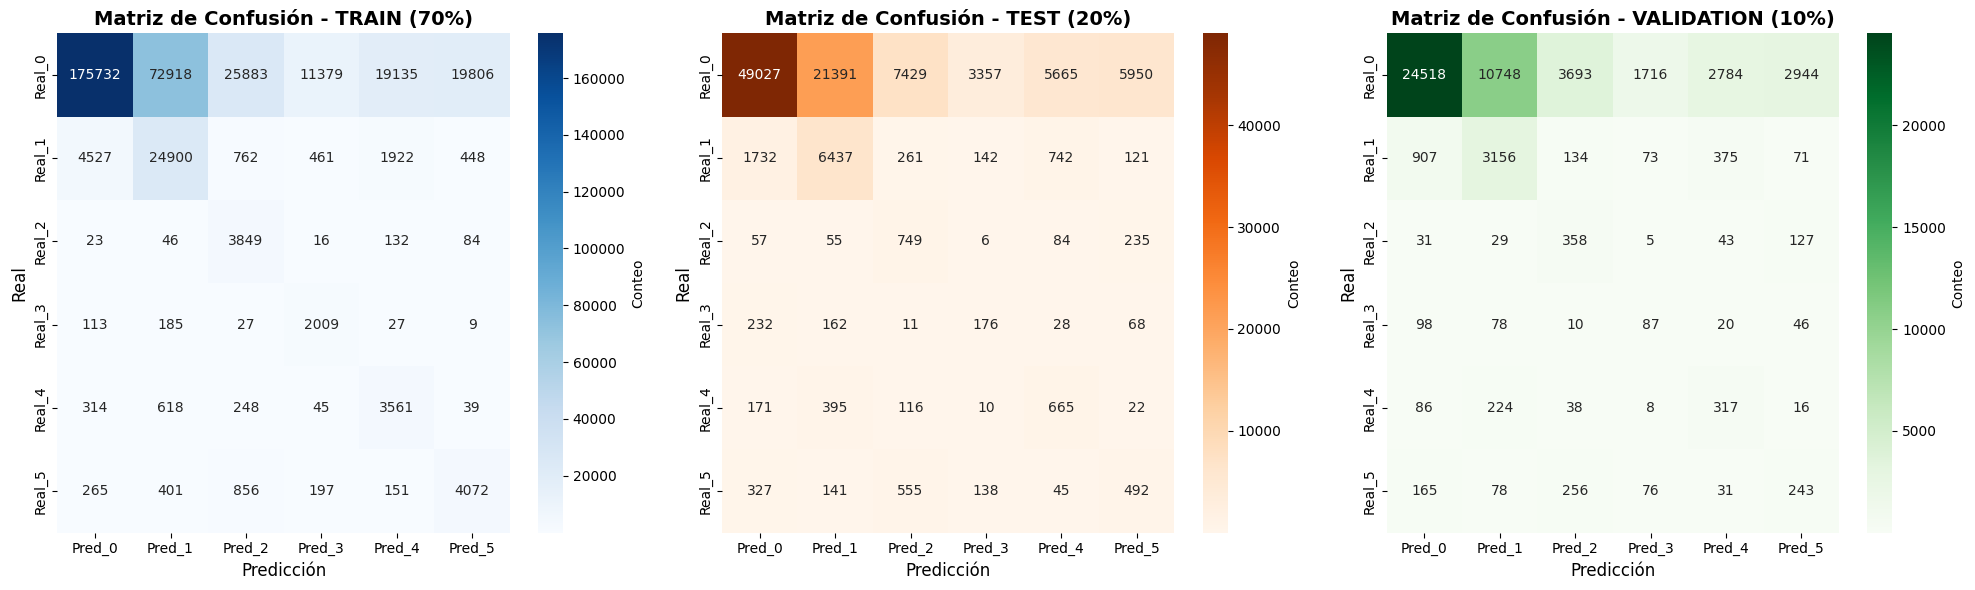

In [343]:
# Visualización de las matrices de confusión
print("="*100)
print("VISUALIZACIÓN DE MATRICES DE CONFUSIÓN")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matriz de confusión - TRAIN
sns.heatmap(cm_train_df, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Conteo'})
axes[0].set_title('Matriz de Confusión - TRAIN (70%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Matriz de confusión - TEST
sns.heatmap(cm_test_df, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Conteo'})
axes[1].set_title('Matriz de Confusión - TEST (20%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

# Matriz de confusión - VALIDATION
sns.heatmap(cm_val_df, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar_kws={'label': 'Conteo'})
axes[2].set_title('Matriz de Confusión - VALIDATION (10%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicción', fontsize=12)
axes[2].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

print("="*100)

In [ ]:
# Resumen de métricas por categoría en formato tabla
from sklearn.metrics import precision_score, recall_score, f1_score

print("="*100)
print("RESUMEN DE MÉTRICAS POR CATEGORÍA - TRAIN / TEST / VALIDATION")
print("="*100)

# Obtener todas las categorías
categorias = sorted(y_test.unique())

# Calcular métricas por categoría
metricas_por_categoria = []

for cat in categorias:
    # Calcular métricas para TRAIN
    precision_train = precision_score(y_train, y_pred_train, labels=[cat], average=None, zero_division=0)[0]
    recall_train = recall_score(y_train, y_pred_train, labels=[cat], average=None, zero_division=0)[0]
    f1_train = f1_score(y_train, y_pred_train, labels=[cat], average=None, zero_division=0)[0]
    soporte_train = (y_train == cat).sum()
    
    # Calcular métricas para TEST
    precision_test = precision_score(y_test, y_pred_test, labels=[cat], average=None, zero_division=0)[0]
    recall_test = recall_score(y_test, y_pred_test, labels=[cat], average=None, zero_division=0)[0]
    f1_test = f1_score(y_test, y_pred_test, labels=[cat], average=None, zero_division=0)[0]
    soporte_test = (y_test == cat).sum()
    
    # Calcular métricas para VALIDATION
    precision_val = precision_score(y_val, y_pred_val, labels=[cat], average=None, zero_division=0)[0]
    recall_val = recall_score(y_val, y_pred_val, labels=[cat], average=None, zero_division=0)[0]
    f1_val = f1_score(y_val, y_pred_val, labels=[cat], average=None, zero_division=0)[0]
    soporte_val = (y_val == cat).sum()
    
    metricas_por_categoria.append({
        'Categoría': cat,
        'Soporte_Train': soporte_train,
        'Precision_Train': precision_train,
        'Recall_Train': recall_train,
        'F1_Train': f1_train,
        'Soporte_Test': soporte_test,
        'Precision_Test': precision_test,
        'Recall_Test': recall_test,
        'F1_Test': f1_test,
        'Soporte_Val': soporte_val,
        'Precision_Val': precision_val,
        'Recall_Val': recall_val,
        'F1_Val': f1_val
    })

df_metricas = pd.DataFrame(metricas_por_categoria)

print("\nMétricas por Categoría (todas las divisiones):")
print(df_metricas.to_string(index=False))

print("\n" + "="*100)
print("INTERPRETACIÓN:")
print("  - Precision: De todas las predicciones de esa categoría, ¿cuántas fueron correctas?")
print("  - Recall: De todos los casos reales de esa categoría, ¿cuántos detectamos?")
print("  - F1-Score: Media armónica entre Precision y Recall")
print("\n  Train (70%), Test (20%), Validation (10%)")
print("="*100)

# Mostrar DataFrame para inspección
df_metricas